In [1]:

import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.
MSSubClass: The building class
MSZoning: The general zoning classification
LotFrontage: Linear feet of street connected to property
LotArea: Lot size in square feet
Street: Type of road access
Alley: Type of alley access
LotShape: General shape of property
LandContour: Flatness of the property
Utilities: Type of utilities available
LotConfig: Lot configuration
LandSlope: Slope of property
Neighborhood: Physical locations within Ames city limits
Condition1: Proximity to main road or railroad
Condition2: Proximity to main road or railroad (if a second is present)
BldgType: Type of dwelling
HouseStyle: Style of dwelling
OverallQual: Overall material and finish quality
OverallCond: Overall condition rating
YearBuilt: Original construction date
YearRemodAdd: Remodel date
RoofStyle: Type of roof
RoofMatl: Roof material
Exterior1st: Exterior covering on house
Exterior2nd: Exterior covering on house (if more than one material)
MasVnrType: Masonry veneer type
MasVnrArea: Masonry veneer area in square feet
ExterQual: Exterior material quality
ExterCond: Present condition of the material on the exterior
Foundation: Type of foundation
BsmtQual: Height of the basement
BsmtCond: General condition of the basement
BsmtExposure: Walkout or garden level basement walls
BsmtFinType1: Quality of basement finished area
BsmtFinSF1: Type 1 finished square feet
BsmtFinType2: Quality of second finished area (if present)
BsmtFinSF2: Type 2 finished square feet
BsmtUnfSF: Unfinished square feet of basement area
TotalBsmtSF: Total square feet of basement area
Heating: Type of heating
HeatingQC: Heating quality and condition
CentralAir: Central air conditioning
Electrical: Electrical system
1stFlrSF: First Floor square feet
2ndFlrSF: Second floor square feet
LowQualFinSF: Low quality finished square feet (all floors)
GrLivArea: Above grade (ground) living area square feet
BsmtFullBath: Basement full bathrooms
BsmtHalfBath: Basement half bathrooms
FullBath: Full bathrooms above grade
HalfBath: Half baths above grade
Bedroom: Number of bedrooms above basement level
Kitchen: Number of kitchens
KitchenQual: Kitchen quality
TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
Functional: Home functionality rating
Fireplaces: Number of fireplaces
FireplaceQu: Fireplace quality
GarageType: Garage location
GarageYrBlt: Year garage was built
GarageFinish: Interior finish of the garage
GarageCars: Size of garage in car capacity
GarageArea: Size of garage in square feet
GarageQual: Garage quality
GarageCond: Garage condition
PavedDrive: Paved driveway
WoodDeckSF: Wood deck area in square feet
OpenPorchSF: Open porch area in square feet
EnclosedPorch: Enclosed porch area in square feet
3SsnPorch: Three season porch area in square feet
ScreenPorch: Screen porch area in square feet
PoolArea: Pool area in square feet
PoolQC: Pool quality
Fence: Fence quality
MiscFeature: Miscellaneous feature not covered in other categories
MiscVal: $Value of miscellaneous feature
MoSold: Month Sold
YrSold: Year Sold
SaleType: Type of sale
SaleCondition: Condition of sale

In [3]:


house_prices_advanced_regression_techniques_path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print('Data source import complete.')


100%|██████████| 199k/199k [00:00<00:00, 69.2MB/s]

Extracting files...
Data source import complete.


In [4]:
!pip install catboost
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, cross_validate, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns
pd.set_option('display.max_row', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width',500)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [5]:
import os

# Reading Train and Test datasets
train_file_path = os.path.join(house_prices_advanced_regression_techniques_path, 'train.csv')
test_file_path = os.path.join(house_prices_advanced_regression_techniques_path, 'test.csv')

train = pd.read_csv(train_file_path)
test = pd.read_csv(test_file_path)

In [6]:
print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


In [7]:
test_ID = test['Id']

In [8]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [10]:
row_train = train.shape[0]
row_test = test.shape[0]
all_data = pd.concat((train, test)).reset_index(drop=True)

In [11]:
all_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [12]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [13]:
all_data.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,486
LotArea,0
Street,0
Alley,2721
LotShape,0
LandContour,0
Utilities,2


In [14]:
# Analyzing variables
def grab_col_names(dataframe, cat_th=10, car_th=20):

    # cat_cols, cat_but_car
    # 1- Categorical variables
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    # 2- Numeric but actually categorical (class)
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                        dataframe[col].dtypes != "O"]

    # 3 - Categorical but actually each cardinal, that is, unique
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                        dataframe[col].dtypes == "O"]

    # 4 - Collect the cat_cols and num_but_cat variables
    cat_cols = cat_cols + num_but_cat

    # 5- Subtract the cardinal variable from cat_cols
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car, num_but_cat

In [15]:
cat_cols, num_cols, cat_but_car, num_but_cat = grab_col_names(all_data)

Observations: 2919
Variables: 81
cat_cols: 52
num_cols: 28
cat_but_car: 1
num_but_cat: 10


In [16]:
# Editing variables with type errors
num_cols.remove("MSSubClass")
num_cols.remove("MoSold")
cat_cols.append("MSSubClass")
cat_cols.append("MoSold")

In [17]:
#Year and month sold are transformed into categorical features.
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)

#MSSubClass=The building class
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)

#Changing OverallCond into a categorical variable
all_data['OverallCond'] = all_data['OverallCond'].astype(str)

In [18]:
# Observe the distribution of numerical and categorical variables in the data.
for col in cat_cols:
    print(pd.DataFrame({col: all_data[col].value_counts(),
                        "Ratio": 100 * all_data[col].value_counts() / len(all_data)}))
    print("######################")

          MSZoning      Ratio
MSZoning                     
RL            2265  77.595067
RM             460  15.758822
FV             139   4.761905
RH              26   0.890716
C (all)         25   0.856458
######################
        Street    Ratio
Street                 
Pave      2907  99.5889
Grvl        12   0.4111
######################
       Alley     Ratio
Alley                 
Grvl     120  4.110997
Pave      78  2.672148
######################
          LotShape      Ratio
LotShape                     
Reg           1859  63.686194
IR1            968  33.162042
IR2             76   2.603631
IR3             16   0.548133
######################
             LandContour      Ratio
LandContour                        
Lvl                 2622  89.825283
HLS                  120   4.110997
Bnk                  117   4.008222
Low                   60   2.055498
######################
           Utilities      Ratio
Utilities                      
AllPub          2916  99.89

In [19]:
all_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,2919.0,1460.000000,842.787043,1.0,730.5,1460.0,2189.5,2919.0
LotFrontage,2433.0,69.305795,23.344905,21.0,59.0,68.0,80.0,313.0
LotArea,2919.0,10168.114080,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
OverallQual,2919.0,6.089072,1.409947,1.0,5.0,6.0,7.0,10.0
YearBuilt,2919.0,1971.312778,30.291442,1872.0,1953.5,1973.0,2001.0,2010.0
YearRemodAdd,2919.0,1984.264474,20.894344,1950.0,1965.0,1993.0,2004.0,2010.0
MasVnrArea,2896.0,102.201312,179.334253,0.0,0.0,0.0,164.0,1600.0
BsmtFinSF1,2918.0,441.423235,455.610826,0.0,0.0,368.5,733.0,5644.0
BsmtFinSF2,2918.0,49.582248,169.205611,0.0,0.0,0.0,0.0,1526.0
BsmtUnfSF,2918.0,560.772104,439.543659,0.0,220.0,467.0,805.5,2336.0


In [20]:
# Performing target variable analysis with categorical variables

def target_with_cat(dataframe, target, cat_col):
    print(cat_col.upper())
    print(pd.DataFrame({"Target_Mean": dataframe.groupby(cat_col)[target].mean(),
                        "Count": dataframe[cat_col].value_counts(),
                        "Ratio": 100 * dataframe[cat_col].value_counts() / len(dataframe)}), end="\n\n\n")

In [21]:
for col in cat_cols:
    target_with_cat(all_data, "SalePrice", col)

MSZONING
            Target_Mean  Count      Ratio
MSZoning                                 
C (all)    74528.000000     25   0.856458
FV        214014.061538    139   4.761905
RH        131558.375000     26   0.890716
RL        191004.994787   2265  77.595067
RM        126316.830275    460  15.758822


STREET
          Target_Mean  Count    Ratio
Street                               
Grvl    130190.500000     12   0.4111
Pave    181130.538514   2907  99.5889


ALLEY
         Target_Mean  Count     Ratio
Alley                                
Grvl   122219.080000    120  4.110997
Pave   168000.585366     78  2.672148


LOTSHAPE
            Target_Mean  Count      Ratio
LotShape                                 
IR1       206101.665289    968  33.162042
IR2       239833.365854     76   2.603631
IR3       216036.500000     16   0.548133
Reg       164754.818378   1859  63.686194


LANDCONTOUR
               Target_Mean  Count      Ratio
LandContour                                 
Bnk      

### 1. Exploratory Data Analysis
Visualizing the distribution of the target variable, missing data, and key correlations.

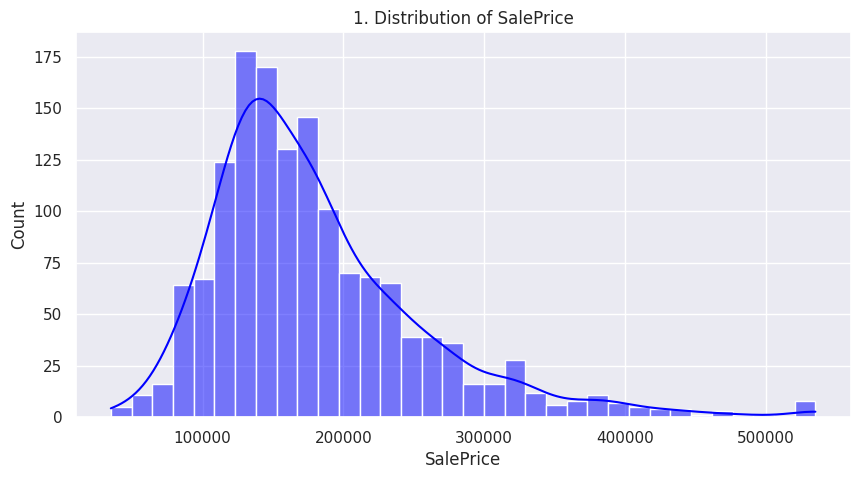

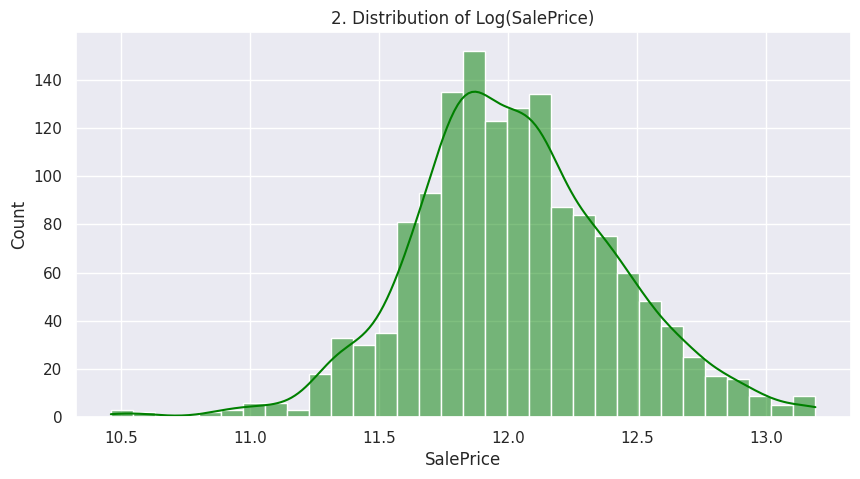

In [93]:
# 1. Target Variable Distribution
plt.figure(figsize=(10, 5))
sns.histplot(plot_df['SalePrice'], kde=True, color='blue')
plt.title('1. Distribution of SalePrice')
plt.show()

# 2. Log-Transformed Target Distribution
plt.figure(figsize=(10, 5))
sns.histplot(np.log(plot_df['SalePrice']), kde=True, color='green')
plt.title('2. Distribution of Log(SalePrice)')
plt.show()

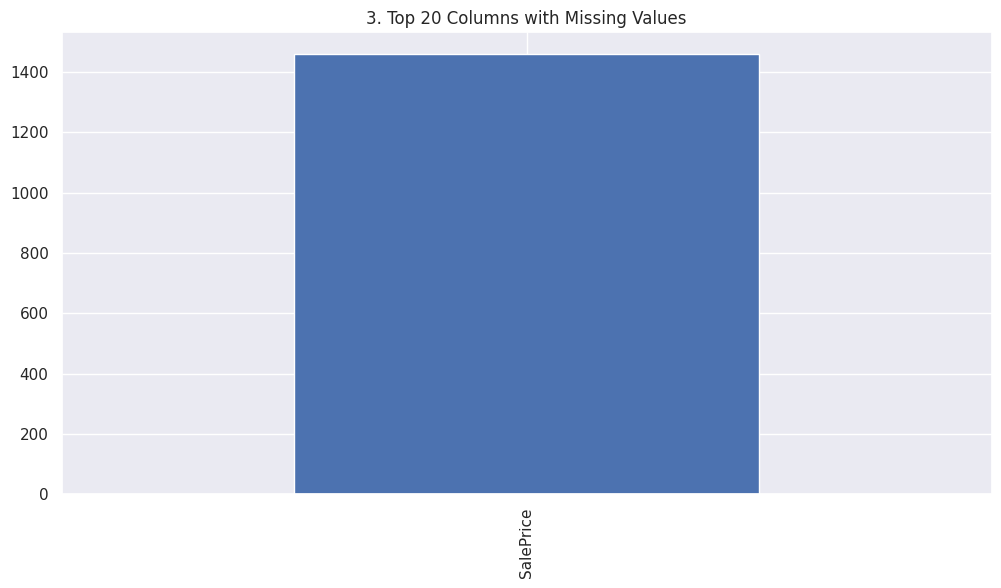

In [94]:
# 3. Missing Values Heatmap (Top 20)
plt.figure(figsize=(12, 6))
missing = all_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)[:20]
if not missing.empty:
    missing.plot(kind='bar')
    plt.title('3. Top 20 Columns with Missing Values')
    plt.show()

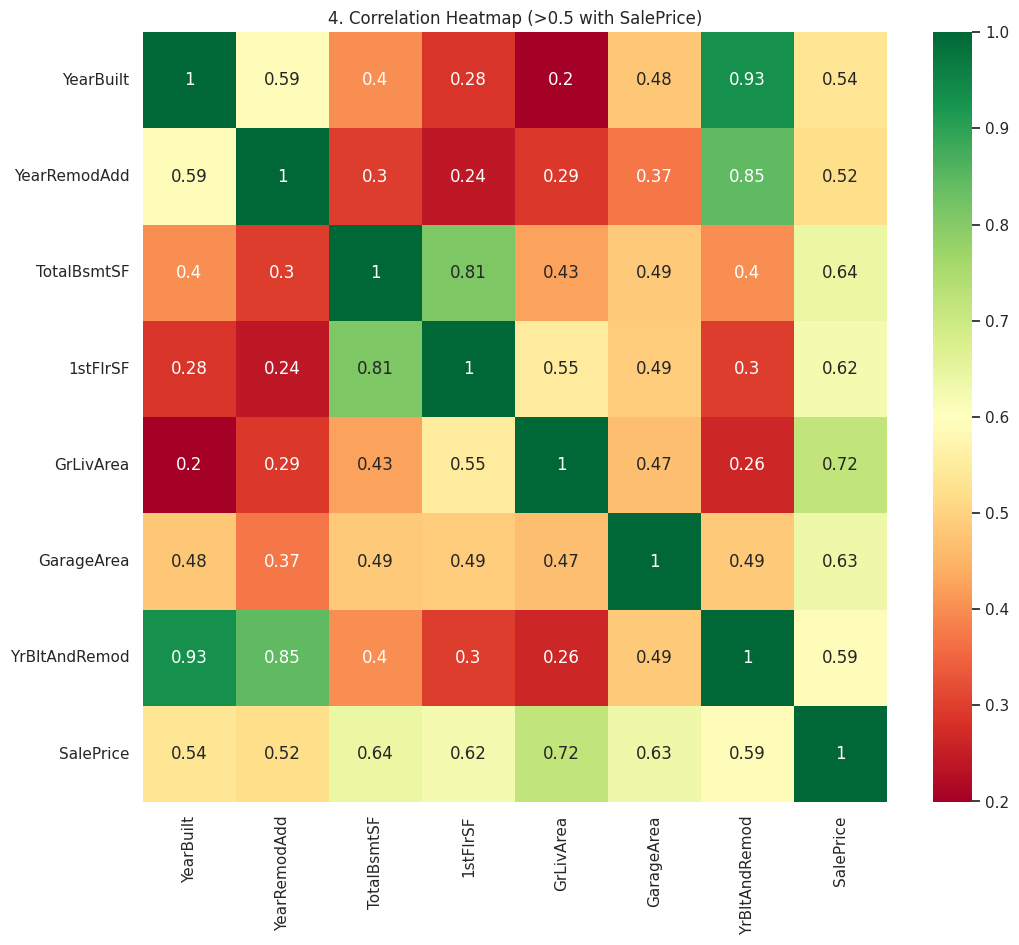

In [95]:
# 4. Correlation Heatmap (Numerical)
plt.figure(figsize=(12, 10))
corr_matrix = plot_df[num_cols + ['SalePrice']].corr()
top_corr_features = corr_matrix.index[abs(corr_matrix['SalePrice']) > 0.5]
sns.heatmap(plot_df[top_corr_features].corr(), annot=True, cmap='RdYlGn')
plt.title('4. Correlation Heatmap (>0.5 with SalePrice)')
plt.show()

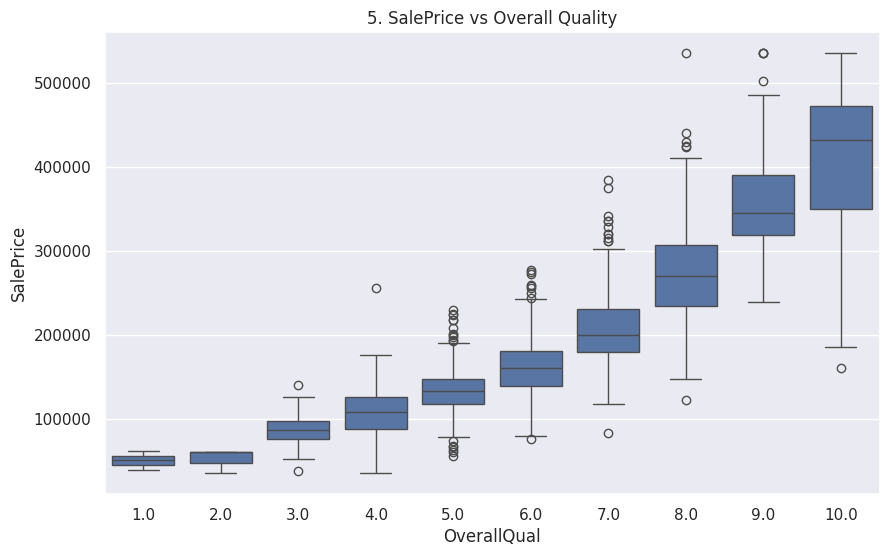

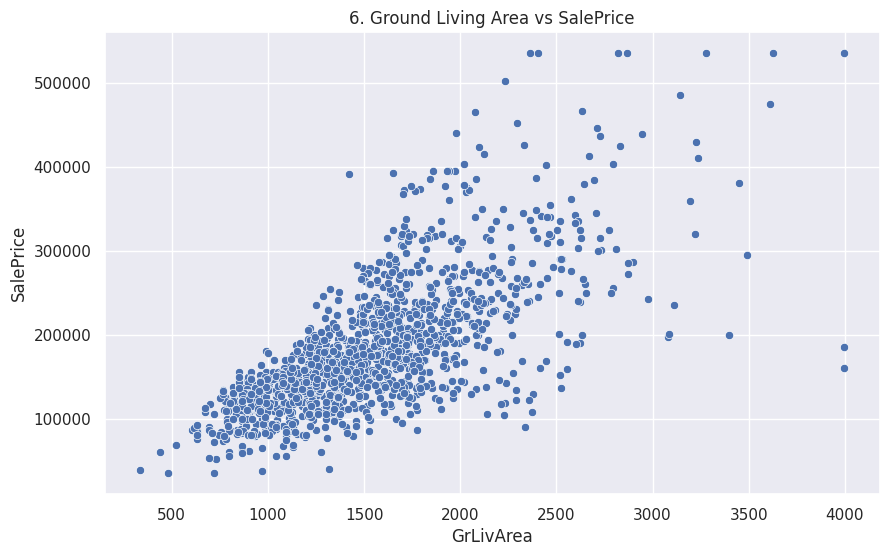

In [96]:
# 5. OverallQual vs SalePrice Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=plot_df)
plt.title('5. SalePrice vs Overall Quality')
plt.show()

# 6. GrLivArea vs SalePrice Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=plot_df)
plt.title('6. Ground Living Area vs SalePrice')
plt.show()

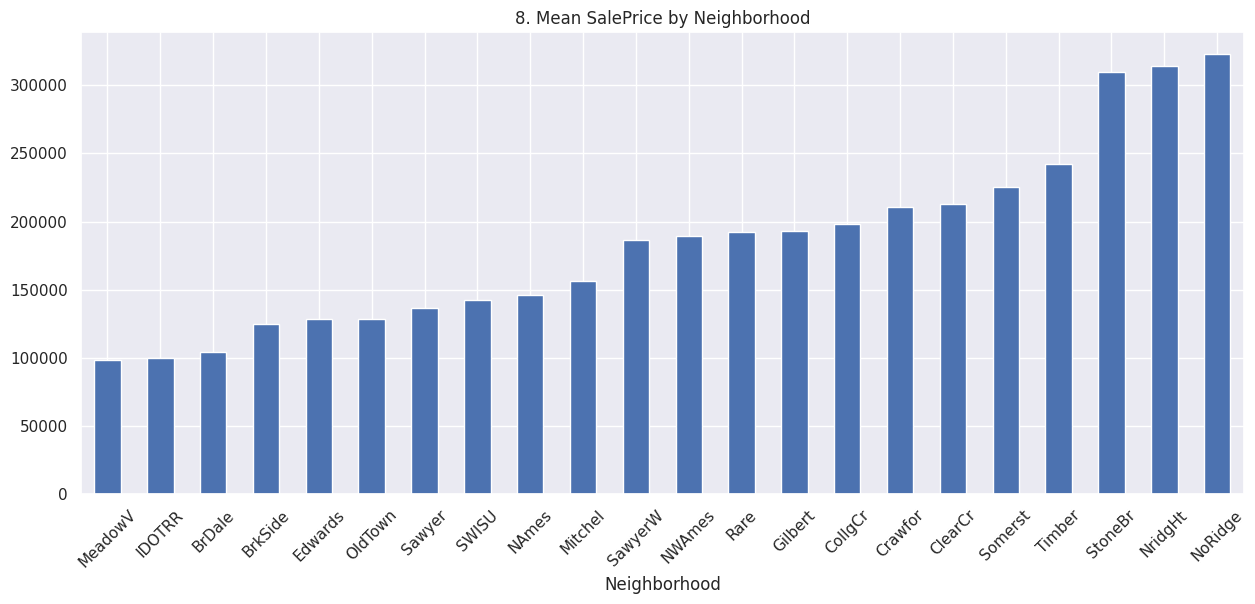

In [97]:
# 8. Mean SalePrice by Neighborhood
plt.figure(figsize=(15, 6))
plot_df.groupby('Neighborhood')['SalePrice'].mean().sort_values().plot(kind='bar')
plt.title('8. Mean SalePrice by Neighborhood')
plt.xticks(rotation=45)
plt.show()

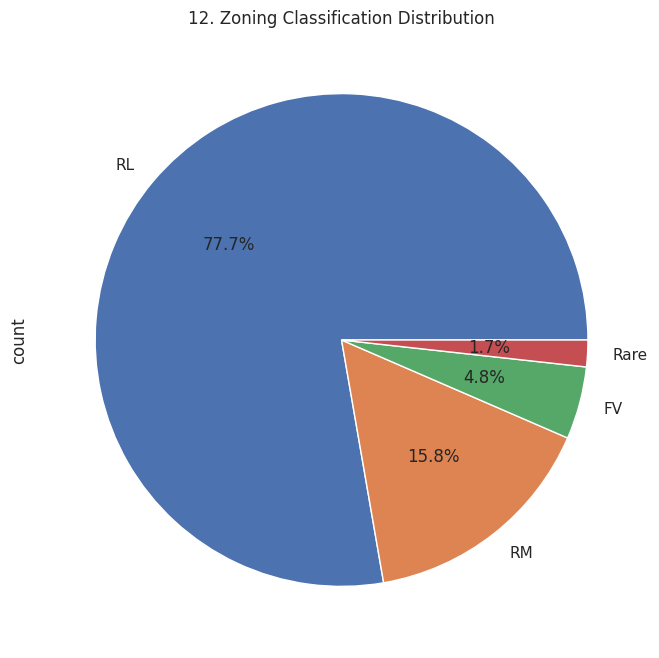

In [98]:
# 12. MSZoning Distribution
plt.figure(figsize=(8, 8))
all_data['MSZoning'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('12. Zoning Classification Distribution')
plt.show()

### Comprehensive Exploratory Data Analysis & Model Evaluation Plots

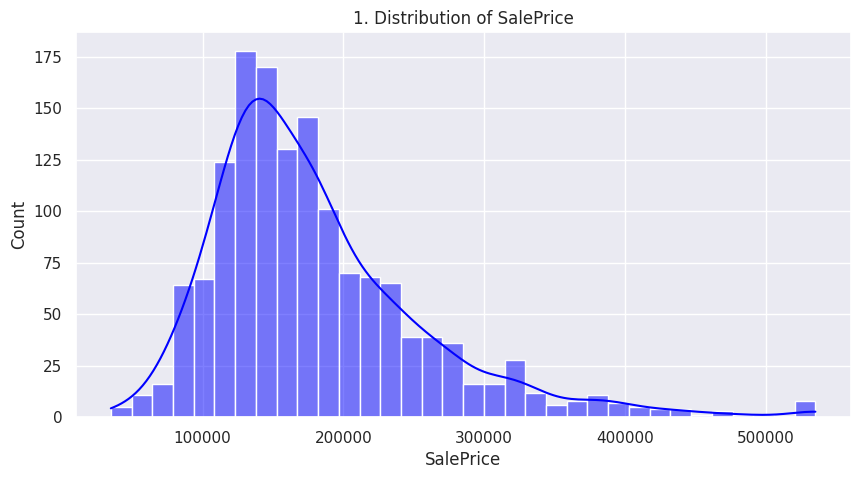

In [62]:
# 1. Target Variable Distribution
plt.figure(figsize=(10, 5))
sns.histplot(plot_df['SalePrice'], kde=True, color='blue')
plt.title('1. Distribution of SalePrice')
plt.show()

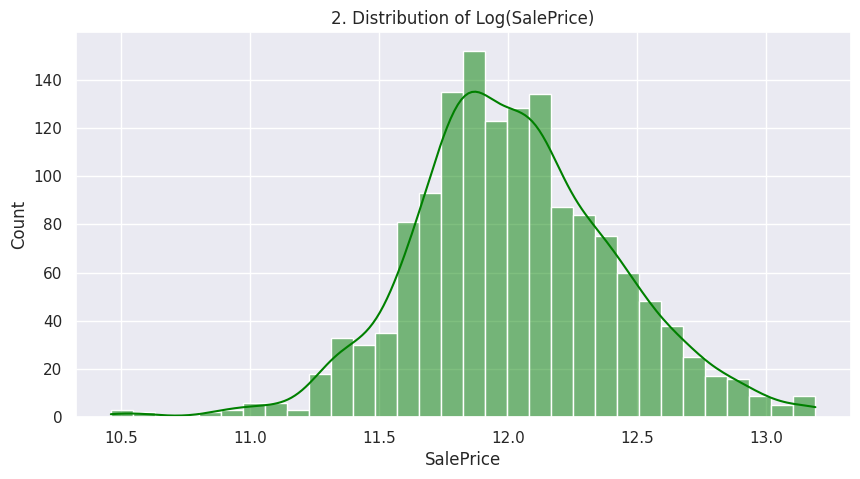

In [63]:
# 2. Log-Transformed Target Distribution
plt.figure(figsize=(10, 5))
sns.histplot(np.log(plot_df['SalePrice']), kde=True, color='green')
plt.title('2. Distribution of Log(SalePrice)')
plt.show()

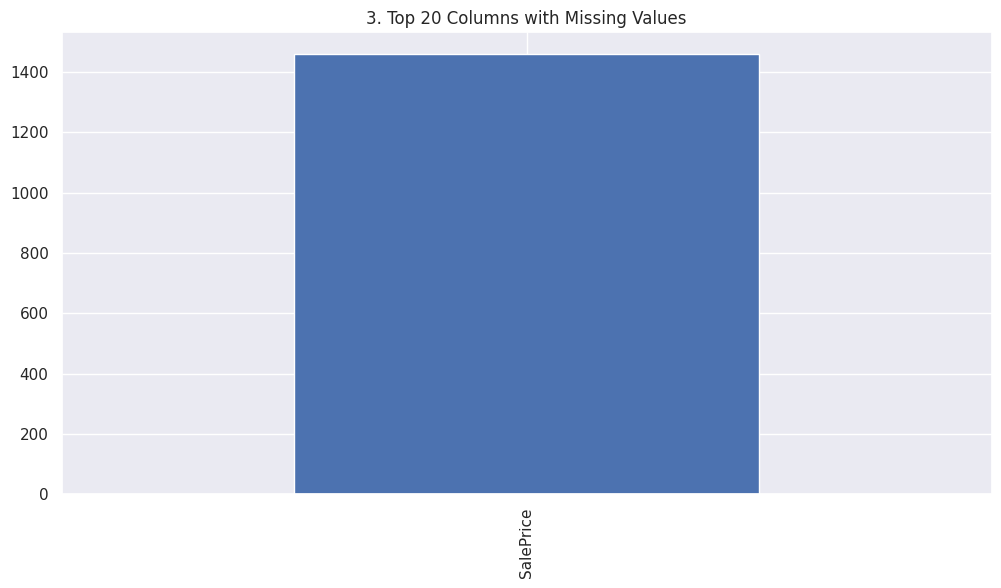

In [64]:
# 3. Missing Values Heatmap (Top 20)
plt.figure(figsize=(12, 6))
missing = all_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)[:20]
if not missing.empty:
    missing.plot(kind='bar')
    plt.title('3. Top 20 Columns with Missing Values')
    plt.show()

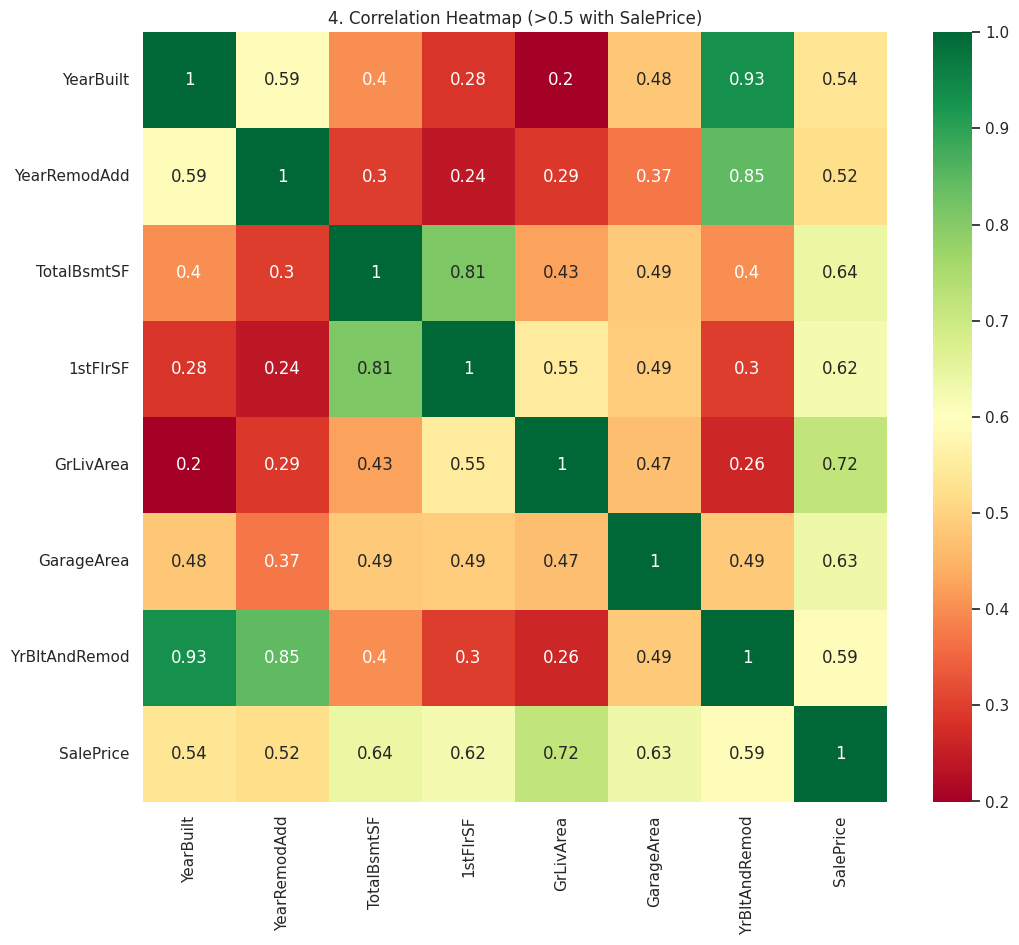

In [65]:
# 4. Correlation Heatmap (Numerical)
plt.figure(figsize=(12, 10))
corr_matrix = plot_df[num_cols + ['SalePrice']].corr()
top_corr_features = corr_matrix.index[abs(corr_matrix['SalePrice']) > 0.5]
sns.heatmap(plot_df[top_corr_features].corr(), annot=True, cmap='RdYlGn')
plt.title('4. Correlation Heatmap (>0.5 with SalePrice)')
plt.show()

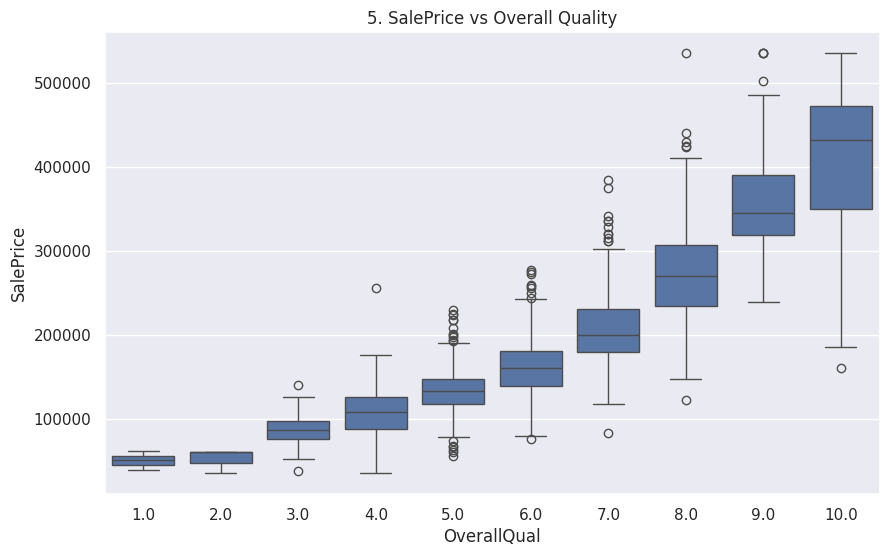

In [66]:
# 5. OverallQual vs SalePrice Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=plot_df)
plt.title('5. SalePrice vs Overall Quality')
plt.show()

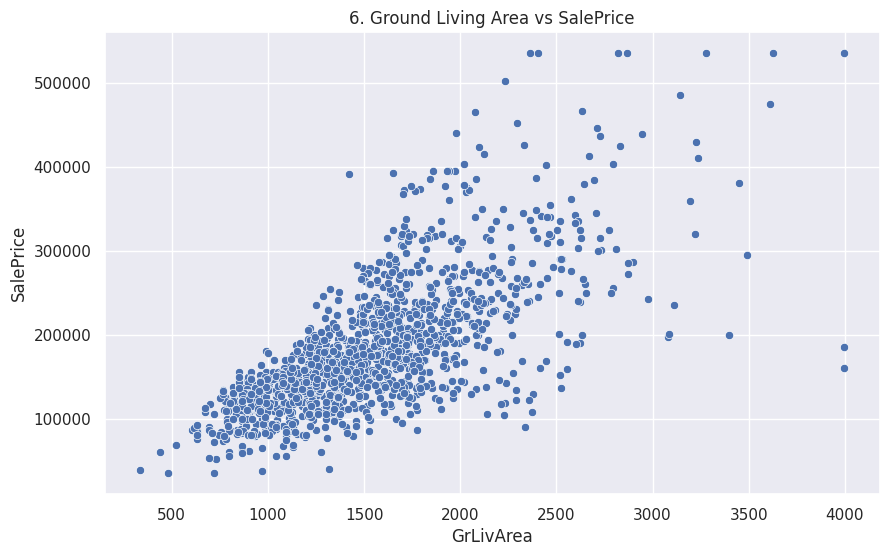

In [67]:
# 6. GrLivArea vs SalePrice Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=plot_df)
plt.title('6. Ground Living Area vs SalePrice')
plt.show()

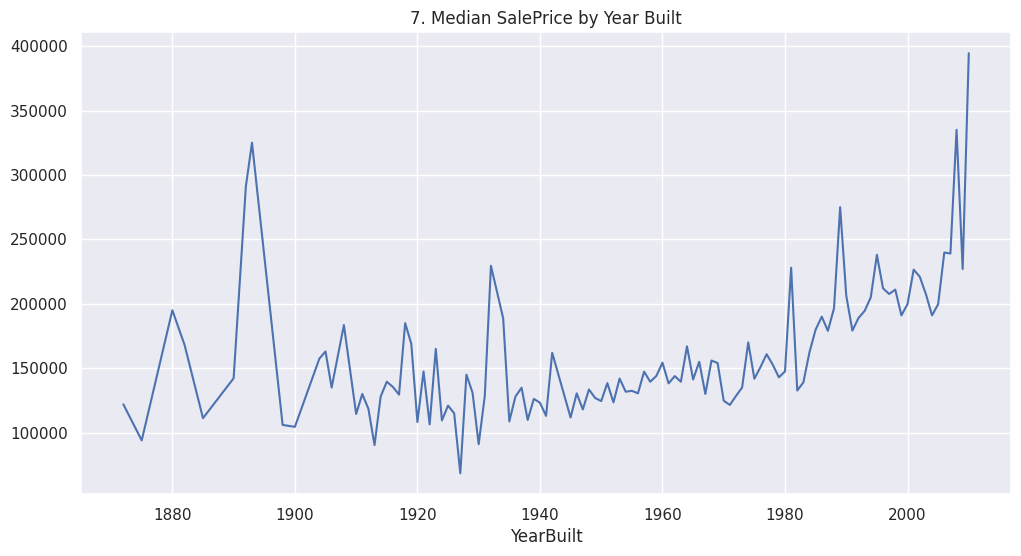

In [68]:
# 7. YearBuilt vs SalePrice LinePlot
plt.figure(figsize=(12, 6))
plot_df.groupby('YearBuilt')['SalePrice'].median().plot()
plt.title('7. Median SalePrice by Year Built')
plt.show()

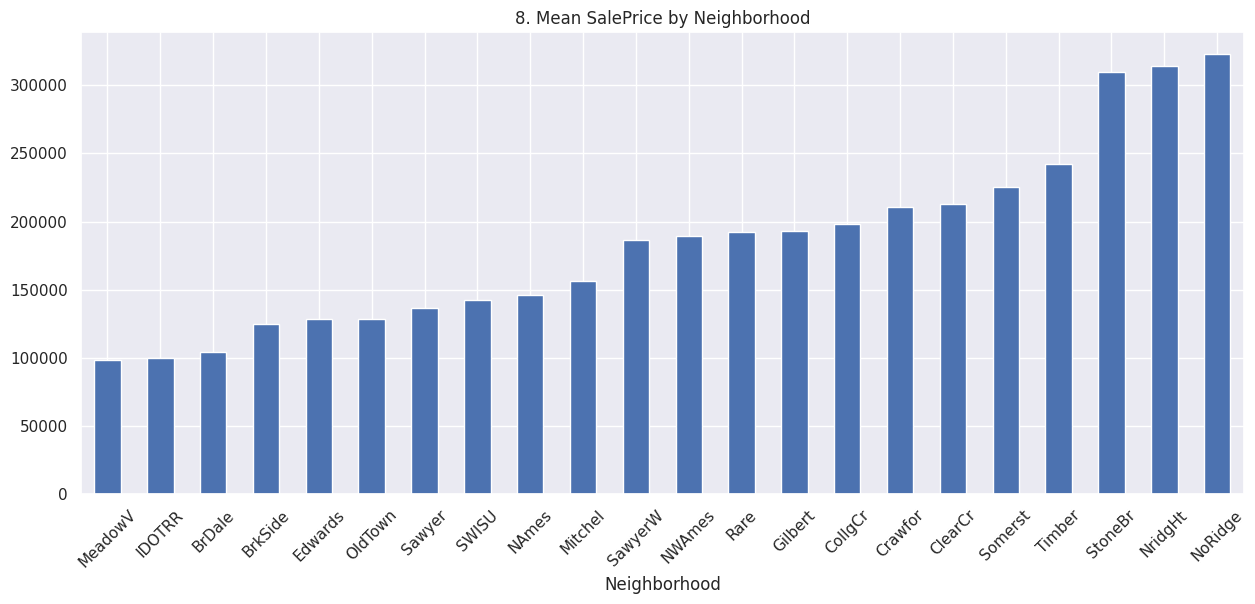

In [69]:
# 8. Neighborhood vs SalePrice
plt.figure(figsize=(15, 6))
plot_df.groupby('Neighborhood')['SalePrice'].mean().sort_values().plot(kind='bar')
plt.title('8. Mean SalePrice by Neighborhood')
plt.xticks(rotation=45)
plt.show()

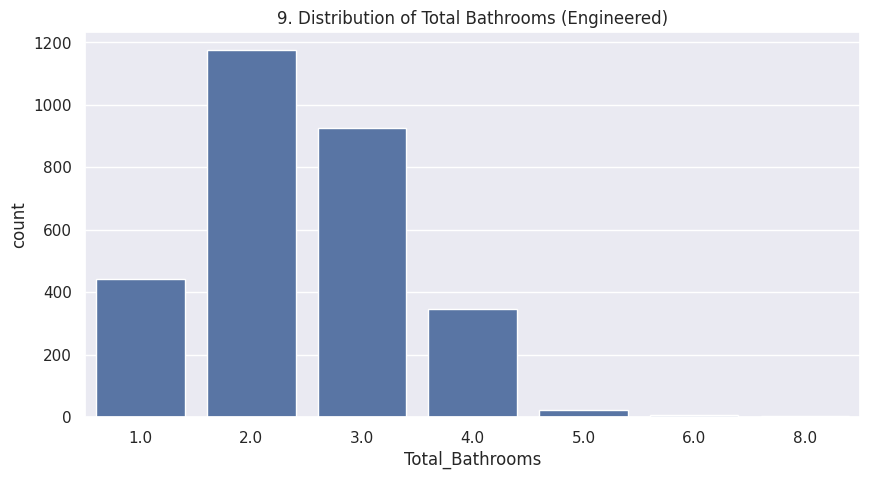

In [70]:
# 9. Total Bathrooms Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='Total_Bathrooms', data=all_data)
plt.title('9. Distribution of Total Bathrooms (Engineered)')
plt.show()

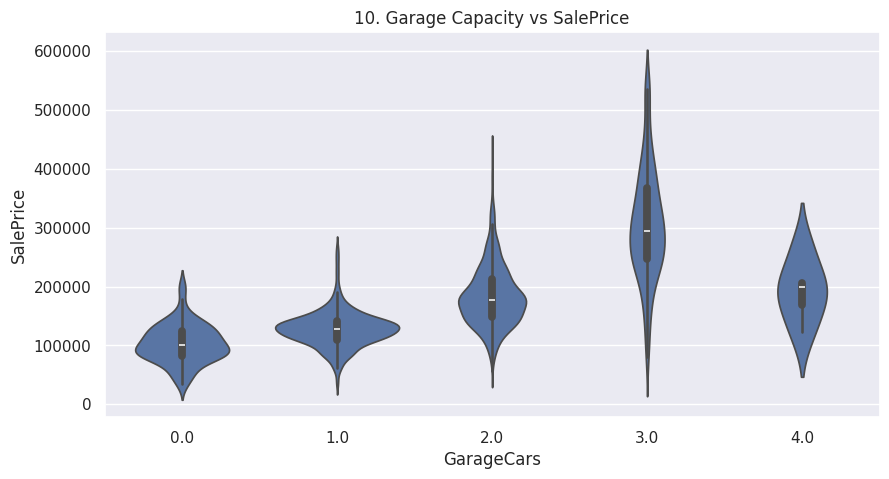

In [71]:
# 10. GarageCars vs SalePrice
plt.figure(figsize=(10, 5))
sns.violinplot(x='GarageCars', y='SalePrice', data=plot_df)
plt.title('10. Garage Capacity vs SalePrice')
plt.show()

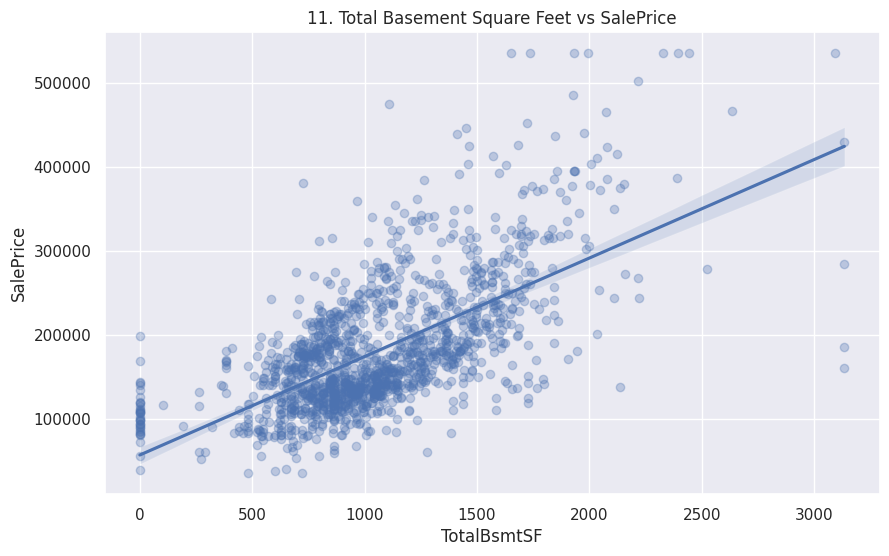

In [72]:
# 11. TotalBsmtSF vs SalePrice
plt.figure(figsize=(10, 6))
sns.regplot(x='TotalBsmtSF', y='SalePrice', data=plot_df, scatter_kws={'alpha':0.3})
plt.title('11. Total Basement Square Feet vs SalePrice')
plt.show()

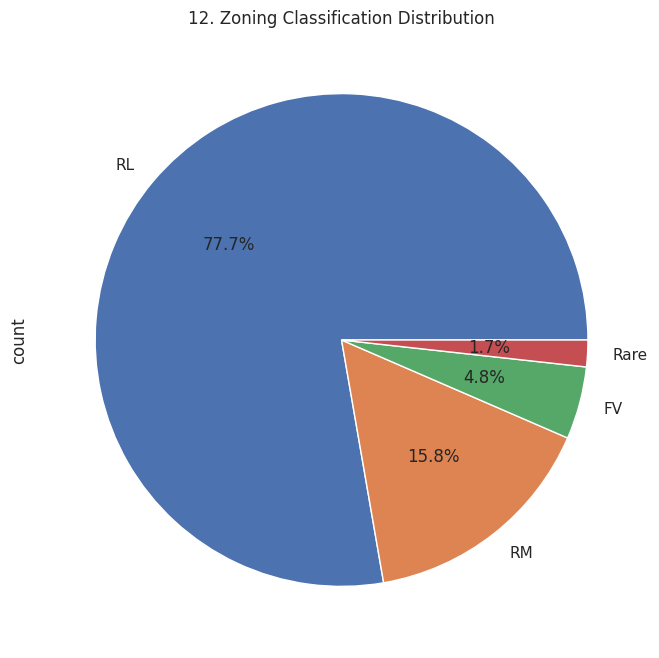

In [73]:
# 12. MSZoning Distribution
plt.figure(figsize=(8, 8))
all_data['MSZoning'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('12. Zoning Classification Distribution')
plt.show()

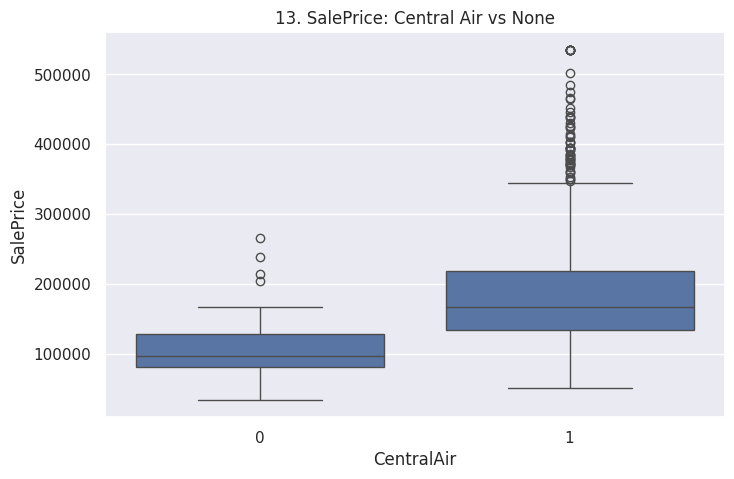

In [74]:
# 13. CentralAir Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='CentralAir', y='SalePrice', data=plot_df)
plt.title('13. SalePrice: Central Air vs None')
plt.show()

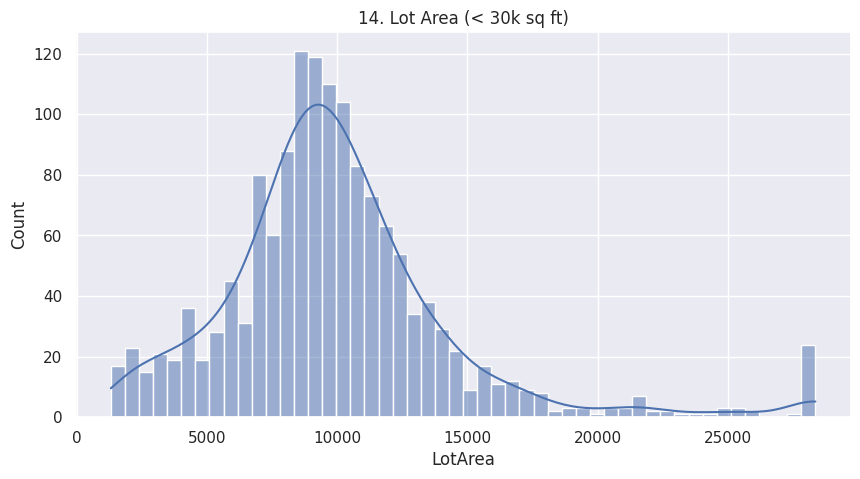

In [75]:
# 14. LotArea Distribution
plt.figure(figsize=(10, 5))
sns.histplot(plot_df[plot_df['LotArea'] < 30000]['LotArea'], bins=50, kde=True)
plt.title('14. Lot Area (< 30k sq ft)')
plt.show()

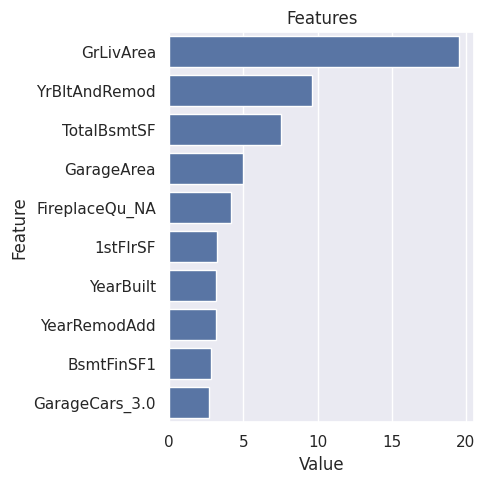

In [76]:
# 15. Feature Importance
plot_importance(final_model, X, num=10)

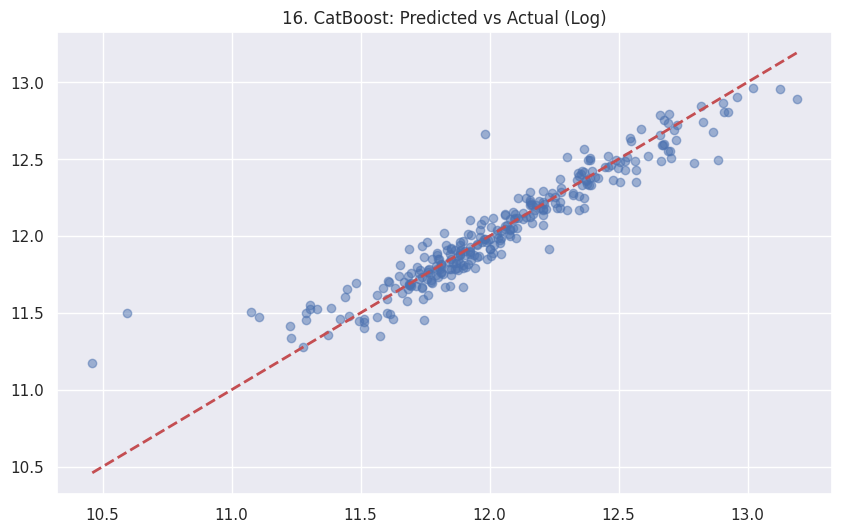

In [77]:
# 16. Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, cat_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('16. CatBoost: Predicted vs Actual (Log)')
plt.show()

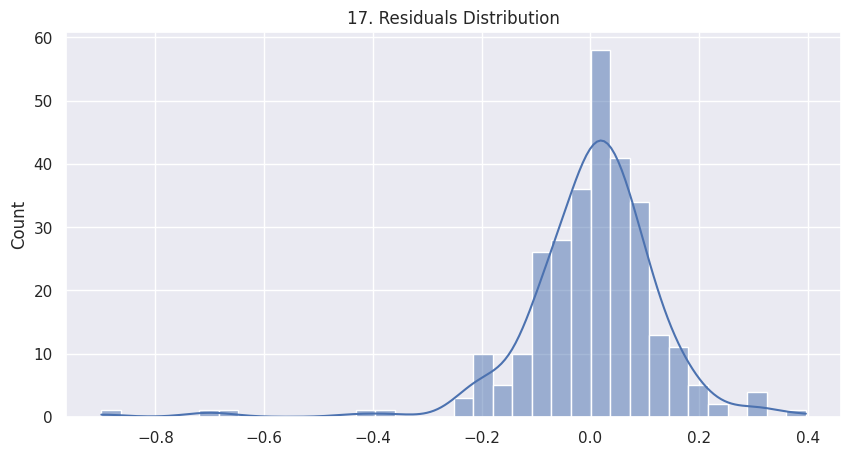

In [78]:
# 17. Residuals
residuals = y_test.flatten() - cat_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title('17. Residuals Distribution')
plt.show()

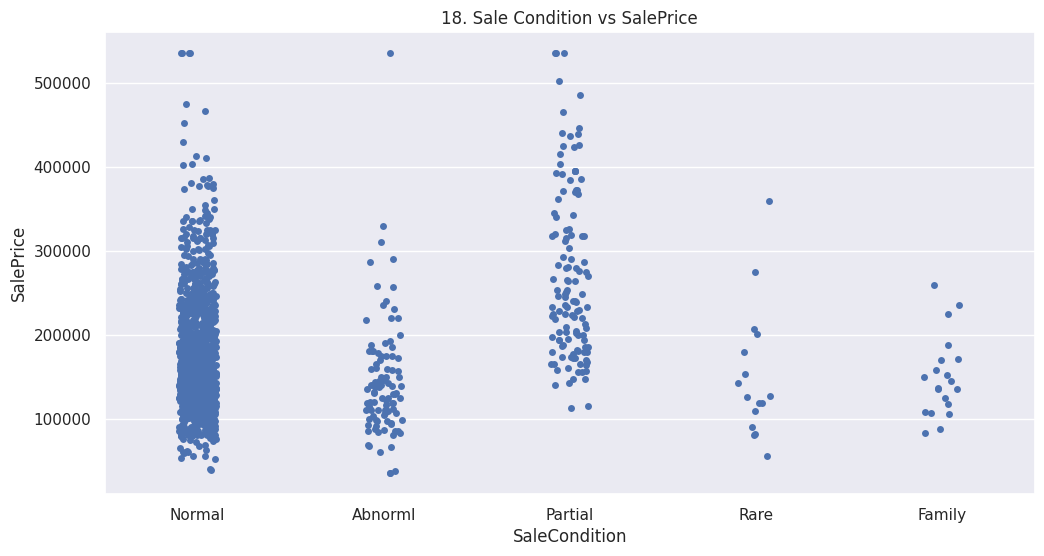

In [79]:
# 18. SaleCondition vs SalePrice
plt.figure(figsize=(12, 6))
sns.stripplot(x='SaleCondition', y='SalePrice', data=plot_df, jitter=True)
plt.title('18. Sale Condition vs SalePrice')
plt.show()

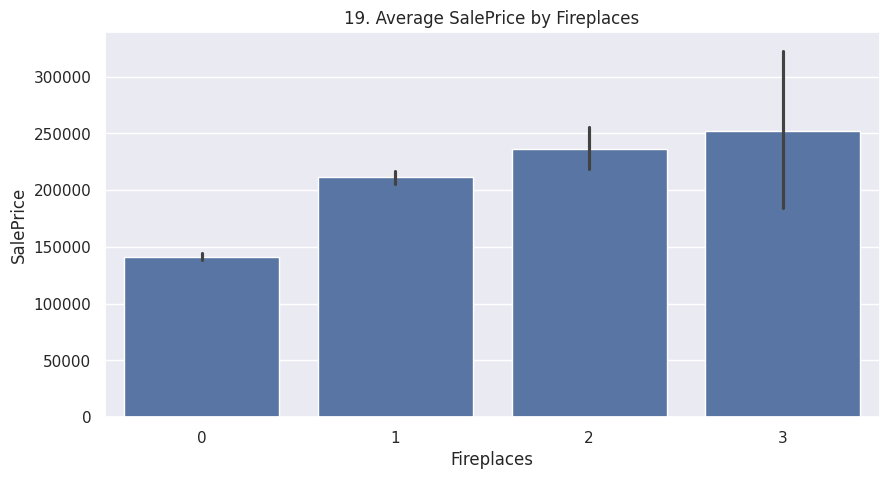

In [80]:
# 19. Fireplaces vs SalePrice
plt.figure(figsize=(10, 5))
sns.barplot(x='Fireplaces', y='SalePrice', data=plot_df)
plt.title('19. Average SalePrice by Fireplaces')
plt.show()

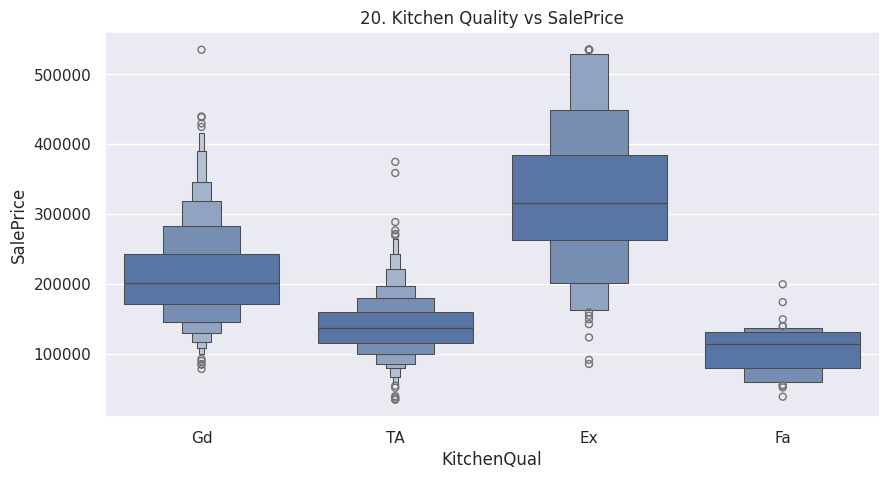

In [81]:
# 20. KitchenQual vs SalePrice
plt.figure(figsize=(10, 5))
sns.boxenplot(x='KitchenQual', y='SalePrice', data=plot_df)
plt.title('20. Kitchen Quality vs SalePrice')
plt.show()

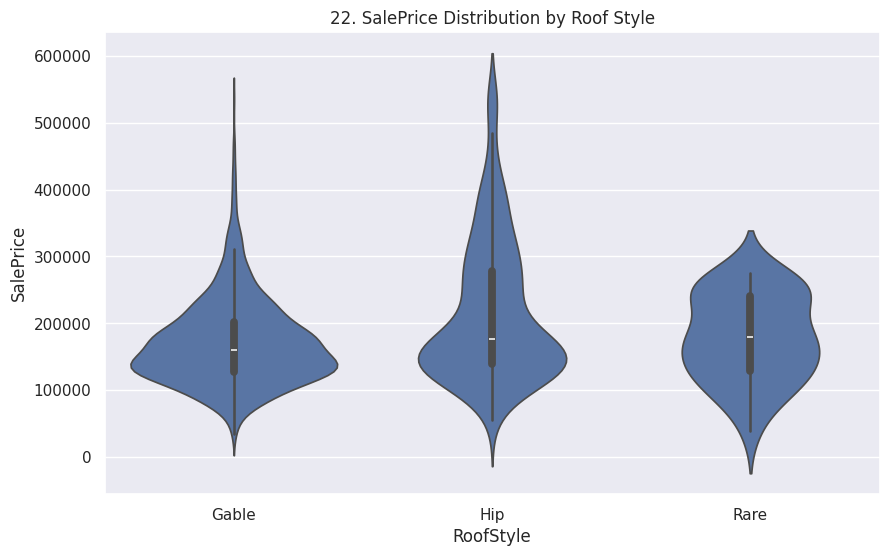

In [83]:
# 22. RoofStyle vs SalePrice
plt.figure(figsize=(10, 6))
sns.violinplot(x='RoofStyle', y='SalePrice', data=plot_df)
plt.title('22. SalePrice Distribution by Roof Style')
plt.show()

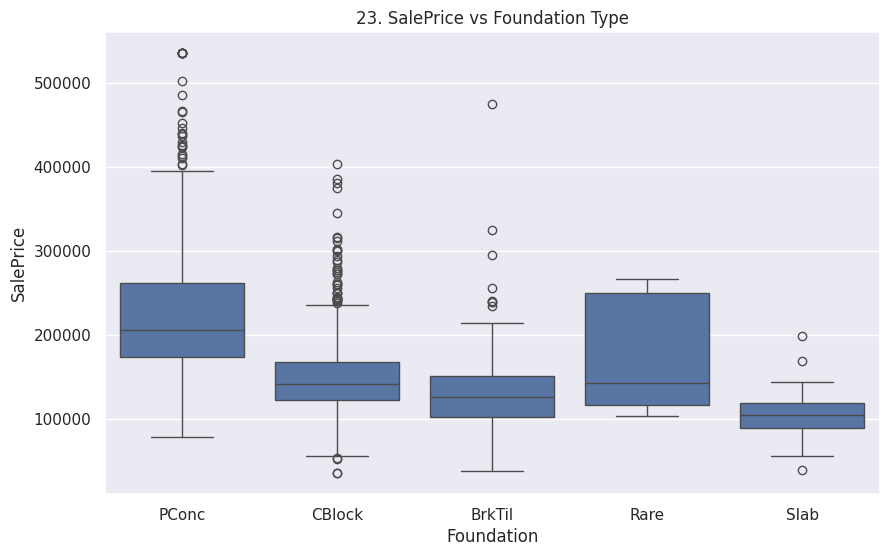

In [84]:
# 23. Foundation vs SalePrice
plt.figure(figsize=(10, 6))
sns.boxplot(x='Foundation', y='SalePrice', data=plot_df)
plt.title('23. SalePrice vs Foundation Type')
plt.show()

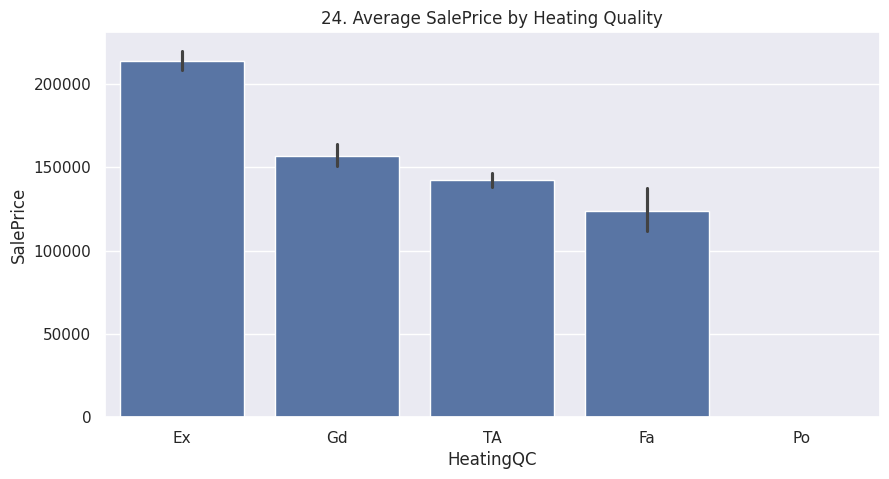

In [85]:
# 24. HeatingQC vs SalePrice
plt.figure(figsize=(10, 5))
sns.barplot(x='HeatingQC', y='SalePrice', data=plot_df, order=['Ex', 'Gd', 'TA', 'Fa', 'Po'])
plt.title('24. Average SalePrice by Heating Quality')
plt.show()

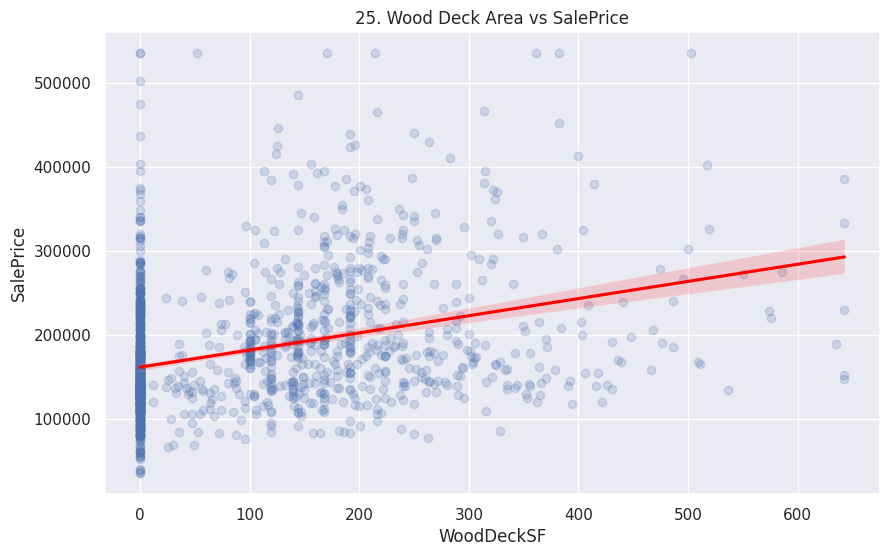

In [86]:
# 25. WoodDeckSF vs SalePrice
plt.figure(figsize=(10, 6))
sns.regplot(x='WoodDeckSF', y='SalePrice', data=plot_df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('25. Wood Deck Area vs SalePrice')
plt.show()

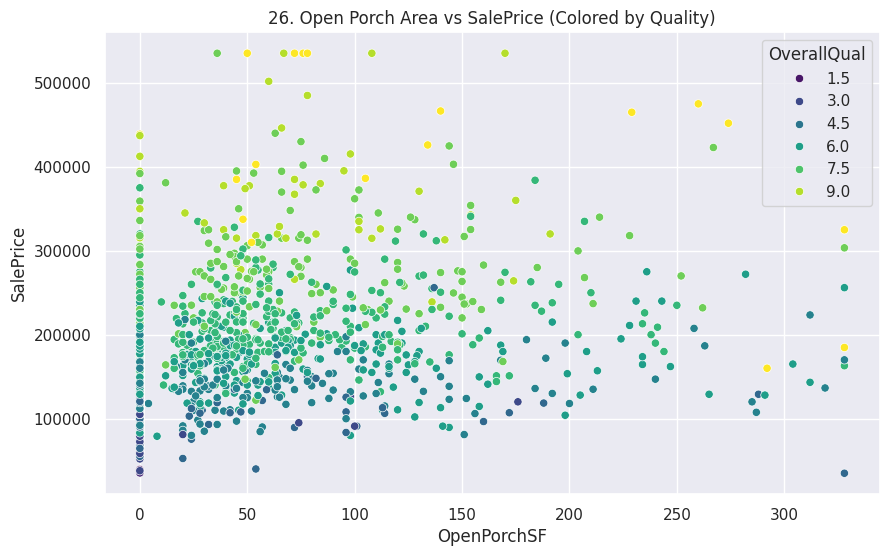

In [87]:
# 26. OpenPorchSF vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(x='OpenPorchSF', y='SalePrice', data=plot_df, hue='OverallQual', palette='viridis')
plt.title('26. Open Porch Area vs SalePrice (Colored by Quality)')
plt.show()

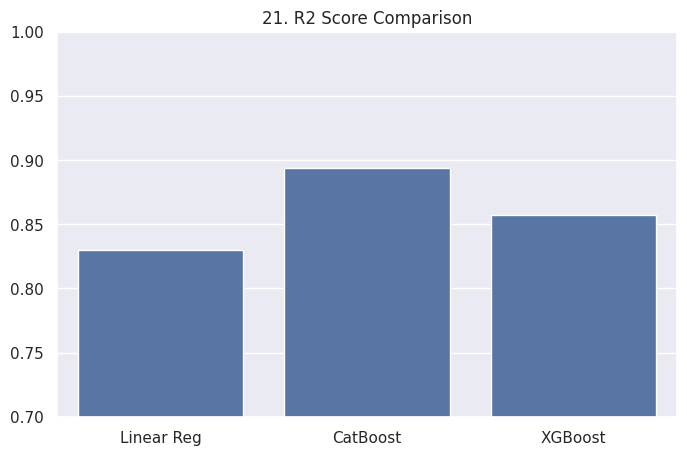

In [82]:
# 21. Model R2 Comparison
models_list = ['Linear Reg', 'CatBoost', 'XGBoost']
scores_list = [liner_r2_score, cb_r2_score, xgb_r2_score]
plt.figure(figsize=(8, 5))
sns.barplot(x=models_list, y=scores_list)
plt.ylim(0.7, 1.0)
plt.title('21. R2 Score Comparison')
plt.show()

/tmp/ipykernel_17631/1126055988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_list, y=mae_list, palette='magma')


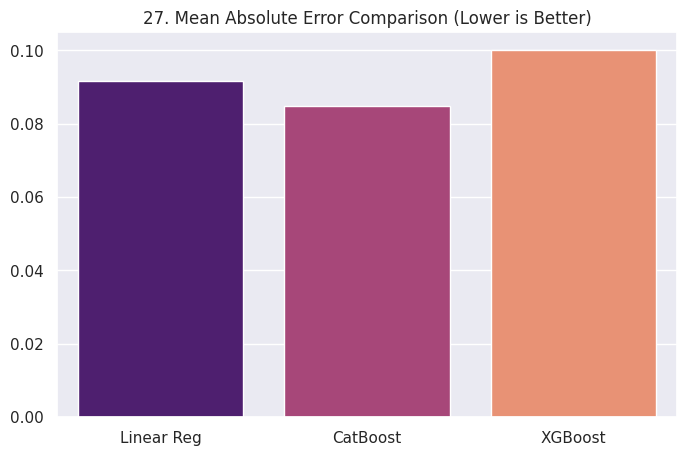

In [88]:
# 27. Model MAE Comparison
mae_list = [metrics.mean_absolute_error(y_test, reg_pred), metrics.mean_absolute_error(y_test, preds), metrics.mean_absolute_error(y_test, xgb_preds)]
plt.figure(figsize=(8, 5))
sns.barplot(x=models_list, y=mae_list, palette='magma')
plt.title('27. Mean Absolute Error Comparison (Lower is Better)')
plt.show()

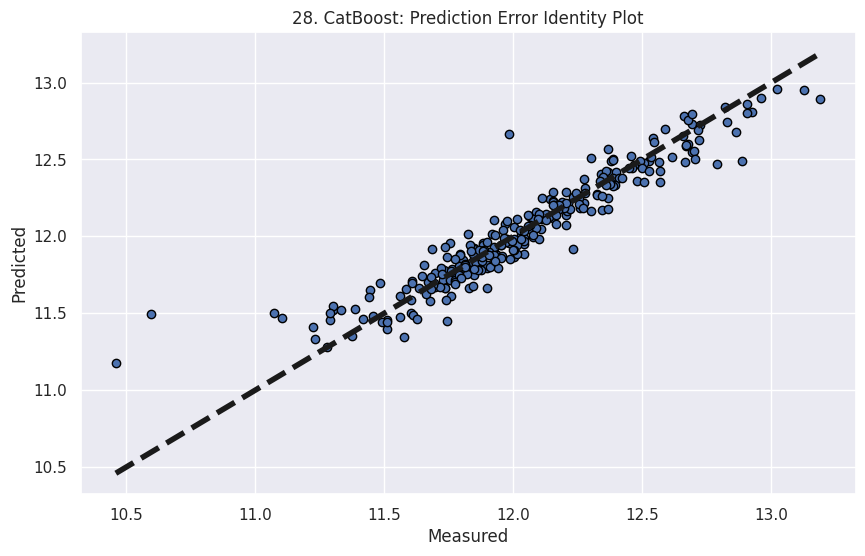

In [89]:
# 28. Prediction Error Plot (CatBoost)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, cat_pred, edgecolors=(0, 0, 0))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
plt.xlabel('Measured')
plt.ylabel('Predicted')
plt.title('28. CatBoost: Prediction Error Identity Plot')
plt.show()

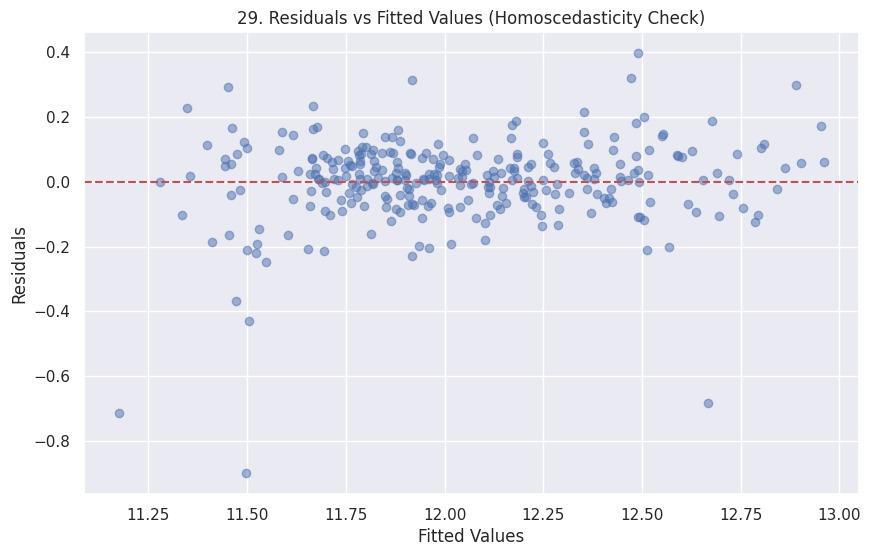

In [90]:
# 29. Residuals vs Fitted
plt.figure(figsize=(10, 6))
plt.scatter(cat_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('29. Residuals vs Fitted Values (Homoscedasticity Check)')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


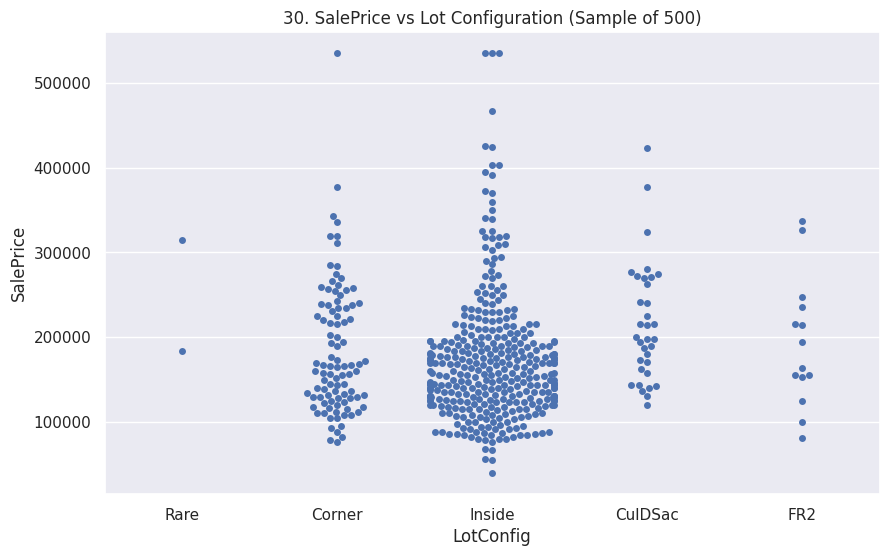

In [91]:
# 30. LotConfig vs SalePrice
plt.figure(figsize=(10, 6))
sns.swarmplot(x='LotConfig', y='SalePrice', data=plot_df.sample(500))
plt.title('30. SalePrice vs Lot Configuration (Sample of 500)')
plt.show()

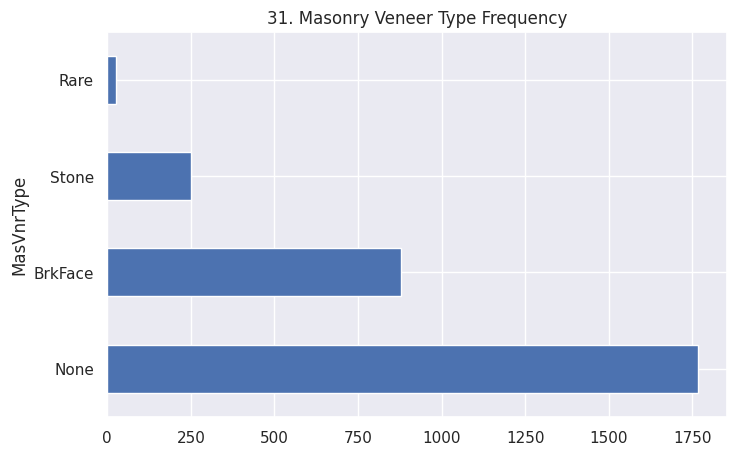

In [92]:
# 31. MasVnrType Distribution
plt.figure(figsize=(8, 5))
all_data['MasVnrType'].value_counts().plot(kind='barh')
plt.title('31. Masonry Veneer Type Frequency')
plt.show()

In [22]:
# Check for any outliers

def outlier_thresholds(dataframe, col_name, q1=0.10, q3=0.90):
        quartile1 = dataframe[col_name].quantile(q1)
        quartile3 = dataframe[col_name].quantile(q3)
        interquantile_range = quartile3 - quartile1
        up_limit = quartile3 + 1.5 * interquantile_range
        low_limit = quartile1 - 1.5 * interquantile_range
        return low_limit, up_limit

In [23]:
def check_outlier(dataframe, col_name):
        low_limit, up_limit = outlier_thresholds(dataframe, col_name)
        if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
            return True
        else:
            return False

In [24]:
for col in num_cols:
    print(col, outlier_thresholds(all_data, col))

Id (np.float64(-3208.8), np.float64(6128.800000000001))
LotFrontage (np.float64(-35.0), np.float64(173.0))
LotArea (np.float64(-9144.900000000001), np.float64(28367.9))
OverallQual (np.float64(0.5), np.float64(12.5))
YearBuilt (np.float64(1801.0), np.float64(2129.0))
YearRemodAdd (np.float64(1865.6999999999996), np.float64(2090.500000000001))
MasVnrArea (np.float64(-488.25), np.float64(813.75))
BsmtFinSF1 (np.float64(-1585.3500000000008), np.float64(2642.2500000000014))
BsmtFinSF2 (np.float64(-188.40000000000055), np.float64(314.0000000000009))
BsmtUnfSF (np.float64(-1678.9000000000005), np.float64(2947.500000000001))
TotalBsmtSF (np.float64(-921.0), np.float64(3135.0))
1stFlrSF (np.float64(-650.5000000000002), np.float64(3070.3))
2ndFlrSF (np.float64(-1387.5), np.float64(2312.5))
LowQualFinSF (np.float64(0.0), np.float64(0.0))
GrLivArea (np.float64(-920.3000000000004), np.float64(3997.3000000000006))
TotRmsAbvGrd (np.float64(0.5), np.float64(12.5))
GarageYrBlt (np.float64(1843.5), np.

# Feature Engineering

In [25]:
# Examination of missing and outlier observations

def replace_with_thresholds(dataframe, col):
    low_limit, up_limit = outlier_thresholds(dataframe, col)
    dataframe.loc[(dataframe[col] < low_limit), col] = low_limit
    dataframe.loc[(dataframe[col] > up_limit), col] = up_limit

for col in num_cols:
    replace_with_thresholds(all_data, col)

# When we check for outliers with the y function, we observe the result.
for col in num_cols:
    print(col, check_outlier(all_data, col))

Id False
LotFrontage False
LotArea False
OverallQual False
YearBuilt False
YearRemodAdd False
MasVnrArea False
BsmtFinSF1 False
BsmtFinSF2 False
BsmtUnfSF False
TotalBsmtSF False
1stFlrSF False
2ndFlrSF False
LowQualFinSF False
GrLivArea False
TotRmsAbvGrd False
GarageYrBlt False
GarageArea False
WoodDeckSF False
OpenPorchSF False
EnclosedPorch False
3SsnPorch False
ScreenPorch False
PoolArea False
MiscVal False
SalePrice False


/tmp/ipykernel_17631/559008493.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-3208.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[col] < low_limit), col] = low_limit
/tmp/ipykernel_17631/559008493.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-9144.900000000001' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[col] < low_limit), col] = low_limit
/tmp/ipykernel_17631/559008493.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[col] < low_limit), col] = low_limit
/tmp/ipykernel_176

In [26]:
all_data["BsmtFinSF1"] = all_data["BsmtFinSF1"].fillna(all_data["BsmtFinSF1"].median())
all_data["BsmtFinSF2"] = all_data["BsmtFinSF2"].fillna(all_data["BsmtFinSF1"].median())
all_data["BsmtUnfSF"] = all_data["BsmtUnfSF"].fillna(all_data["BsmtFinSF1"].median())
all_data["TotalBsmtSF"] = all_data["TotalBsmtSF"].fillna(all_data["BsmtFinSF1"].median())
all_data["GarageYrBlt"] = all_data["GarageYrBlt"].fillna(all_data["BsmtFinSF1"].median())
all_data["GarageArea"] = all_data["GarageArea"].fillna(all_data["BsmtFinSF1"].median())
all_data["LotFrontage"] = all_data["LotFrontage"].fillna(all_data["BsmtFinSF1"].median())
all_data["MasVnrArea"] = all_data["MasVnrArea"].fillna(all_data["BsmtFinSF1"].median())

In [27]:
all_data['GarageCars'] = all_data['GarageCars'].fillna(all_data['GarageCars'].mode()[0])

In [28]:
all_data["Functional"] = all_data["Functional"].fillna("Typ")
all_data["GarageQual"] = all_data["GarageQual"].fillna("NA")
all_data["GarageCond"] = all_data["GarageCond"].fillna("NA")
all_data["PoolQC"] = all_data["PoolQC"].fillna("NA")
all_data["Fence"] = all_data["Fence"].fillna("NA")
all_data["MiscFeature"] = all_data["MiscFeature"].fillna("NA")
all_data["Alley"] = all_data["Alley"].fillna("NA")
all_data["FireplaceQu"] = all_data["FireplaceQu"].fillna("NA")
all_data["GarageType"] = all_data["GarageType"].fillna("NA")
all_data["GarageFinish"] = all_data["GarageFinish"].fillna("NA")
all_data["BsmtQual"] = all_data["BsmtQual"].fillna("NA")
all_data["BsmtCond"] = all_data["BsmtCond"].fillna("NA")
all_data["BsmtExposure"] = all_data["BsmtExposure"].fillna("NA")
all_data["BsmtFinType1"] = all_data["BsmtFinType1"].fillna("NA")
all_data["BsmtFinType2"] = all_data["BsmtFinType2"].fillna("NA")

In [29]:
all_data['Utilities'] = all_data['Utilities'].fillna(all_data['Utilities'].mode()[0])
all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])
all_data['BsmtFullBath'] = all_data['BsmtFullBath'].fillna(all_data['BsmtFullBath'].mode()[0])
all_data['BsmtHalfBath'] = all_data['BsmtHalfBath'].fillna(all_data['BsmtHalfBath'].mode()[0])
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])

In [30]:
all_data["Exterior1st"] = all_data["Exterior1st"].fillna("other")
all_data["Exterior2nd"] = all_data["Exterior2nd"].fillna("other")
all_data["MasVnrType"] = all_data["MasVnrType"].fillna("None")
all_data["SaleType"] = all_data["SaleType"].fillna("Oth")
all_data["Electrical"] = all_data["Electrical"].fillna("Mix")

In [31]:
# Rare Encoder implementation

def rare_encoder(dataframe, rare_perc):
    temp_df = dataframe.copy()

    rare_columns = [col for col in temp_df.columns if temp_df[col].dtypes == 'O'
                    and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])

    return temp_df

In [32]:
all_data=rare_encoder(all_data, 0.01)
all_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1.0,60,RL,65.0,8450.0,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7.0,5,2003,2003.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856.0,854.0,0,1710.0,1.0,0.0,2,1,3,1,Gd,8.0,Typ,0,NA,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0.0,61.0,0,0,0,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
1,2.0,20,RL,80.0,9600.0,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Rare,Feedr,Norm,1Fam,1Story,6.0,8,1976,1976.0,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262.0,0.0,0,1262.0,0.0,1.0,2,0,3,1,TA,6.0,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298.0,0.0,0,0,0,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
2,3.0,60,RL,68.0,11250.0,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7.0,5,2001,2002.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920.0,866.0,0,1786.0,1.0,0.0,2,1,3,1,Gd,6.0,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0.0,42.0,0,0,0,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
3,4.0,70,RL,60.0,9550.0,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7.0,5,1915,1970.0,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961.0,756.0,0,1717.0,1.0,0.0,1,0,3,1,Gd,7.0,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0.0,35.0,272,0,0,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
4,5.0,60,RL,84.0,14260.0,Pave,NA,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8.0,5,2000,2000.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145.0,1053.0,0,2198.0,1.0,0.0,2,1,4,1,Gd,9.0,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192.0,84.0,0,0,0,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0


In [33]:
# Creating new variables

all_data['Total_Bathrooms'] = (all_data['FullBath'] + all_data['HalfBath'] + all_data['BsmtFullBath'] + all_data['BsmtHalfBath'])

all_data['YrBltAndRemod'] = all_data['YearBuilt'] + all_data['YearRemodAdd']

all_data['Totallot'] = all_data['LotFrontage'] + all_data['LotArea']

In [34]:
# Encoding

def label_encoder(dataframe, binary_cols):
    dataframe[binary_cols] = LabelEncoder().fit_transform(dataframe[binary_cols])
    return dataframe

binary_cols = [col for col in all_data.columns if all_data[col].dtype == "O" and all_data[col].nunique() == 2]
for col in binary_cols:
    all_data = label_encoder(all_data, col)


# OneHot encoder

def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

cols = [col for col in all_data.columns if 22 >= all_data[col].nunique() > 2]

df2 = one_hot_encoder(all_data, cols)

df2.head()

,Id,LotFrontage,LotArea,Street,Utilities,Condition2,YearBuilt,YearRemodAdd,RoofMatl,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,SalePrice,YrBltAndRemod,Totallot,MSSubClass_160,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_Rare,MSZoning_RL,MSZoning_RM,MSZoning_Rare,Alley_NA,Alley_Pave,LotShape_IR2,LotShape_Rare,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_Inside,LotConfig_Rare,LandSlope_Mod,LandSlope_Rare,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_Rare,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Condition1_Feedr,Condition1_Norm,Condition1_PosN,Condition1_RRAn,Condition1_Rare,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_Rare,HouseStyle_SFoyer,HouseStyle_SLvl,OverallQual_2.0,OverallQual_3.0,OverallQual_4.0,OverallQual_5.0,OverallQual_6.0,OverallQual_7.0,OverallQual_8.0,OverallQual_9.0,OverallQual_10.0,OverallCond_4,OverallCond_5,OverallCond_6,OverallCond_7,OverallCond_8,OverallCond_9,OverallCond_Rare,RoofStyle_Hip,RoofStyle_Rare,Exterior1st_BrkFace,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Rare,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_BrkFace,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Rare,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_None,MasVnrType_Rare,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Gd,ExterCond_Rare,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Rare,Foundation_Slab,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_NA,BsmtQual_TA,BsmtCond_Gd,BsmtCond_NA,BsmtCond_Rare,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_NA,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_NA,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_NA,BsmtFinType2_Rec,BsmtFinType2_Unf,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Rare,HeatingQC_TA,Electrical_FuseF,Electrical_Rare,Electrical_SBrkr,BsmtFullBath_1.0,BsmtFullBath_2.0,BsmtFullBath_3.0,BsmtHalfBath_1.0,BsmtHalfBath_2.0,FullBath_1,FullBath_2,FullBath_3,FullBath_4,HalfBath_1,HalfBath_2,BedroomAbvGr_1,BedroomAbvGr_2,BedroomAbvGr_3,BedroomAbvGr_4,BedroomAbvGr_5,BedroomAbvGr_6,BedroomAbvGr_8,KitchenAbvGr_1,KitchenAbvGr_2,KitchenAbvGr_3,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,TotRmsAbvGrd_3.0,TotRmsAbvGrd_4.0,TotRmsAbvGrd_5.0,TotRmsAbvGrd_6.0,TotRmsAbvGrd_7.0,TotRmsAbvGrd_8.0,TotRmsAbvGrd_9.0,TotRmsAbvGrd_10.0,TotRmsAbvGrd_11.0,TotRmsAbvGrd_12.0,TotRmsAbvGrd_12.5,Functional_Min2,Functional_Mod,Functional_Rare,Functional_Typ,Fireplaces_1,Fireplaces_2,Fireplaces_3,Fireplaces_4,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_NA,FireplaceQu_Po,FireplaceQu_TA,GarageType_Basment,GarageType_BuiltIn,GarageType_Detchd,GarageType_NA,GarageType_Rare,GarageFinish_NA,GarageFinish_RFn,GarageFinish_Unf,GarageCars_1.0,GarageCars_2.0,GarageCars_3.0,GarageCars_4.0,GarageCars_5.0,GarageQual_NA,GarageQual_Rare,GarageQual_TA,GarageCond_NA,GarageCond_Rare,GarageCond_TA,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_NA,Fence_Rare,MiscFeature_Rare,MiscFeature_Shed,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2

### 2. Feature Engineering Analysis
Visualizing the distribution of engineered variables and their relationships with price.

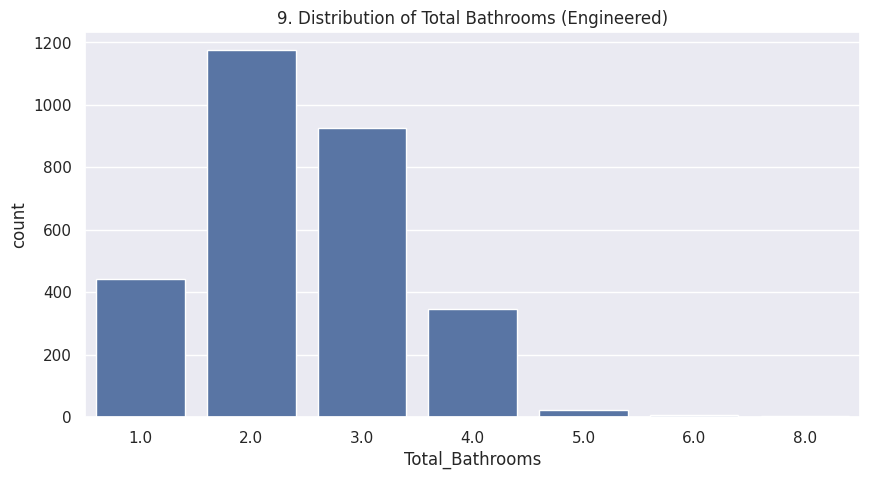

In [99]:
# 9. Total Bathrooms Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='Total_Bathrooms', data=all_data)
plt.title('9. Distribution of Total Bathrooms (Engineered)')
plt.show()

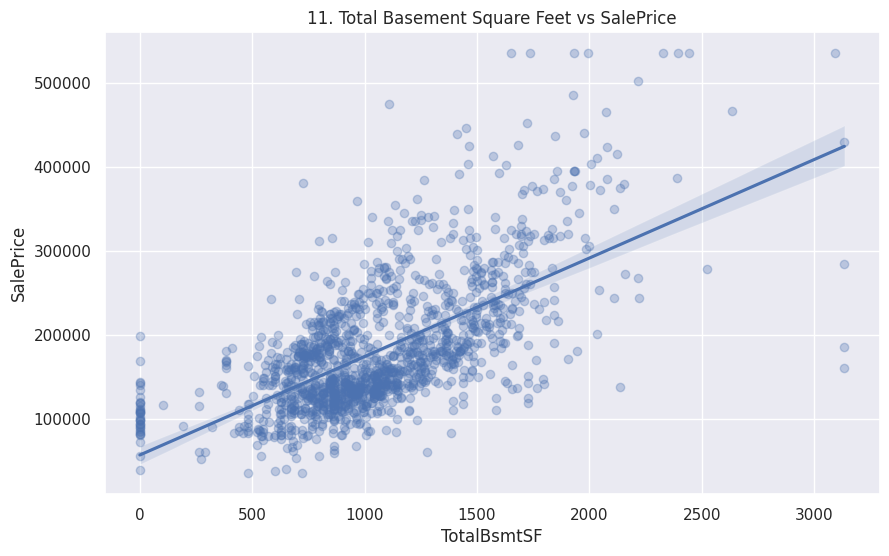

In [100]:
# 11. Total Basement Square Feet vs SalePrice
plt.figure(figsize=(10, 6))
sns.regplot(x='TotalBsmtSF', y='SalePrice', data=plot_df, scatter_kws={'alpha':0.3})
plt.title('11. Total Basement Square Feet vs SalePrice')
plt.show()

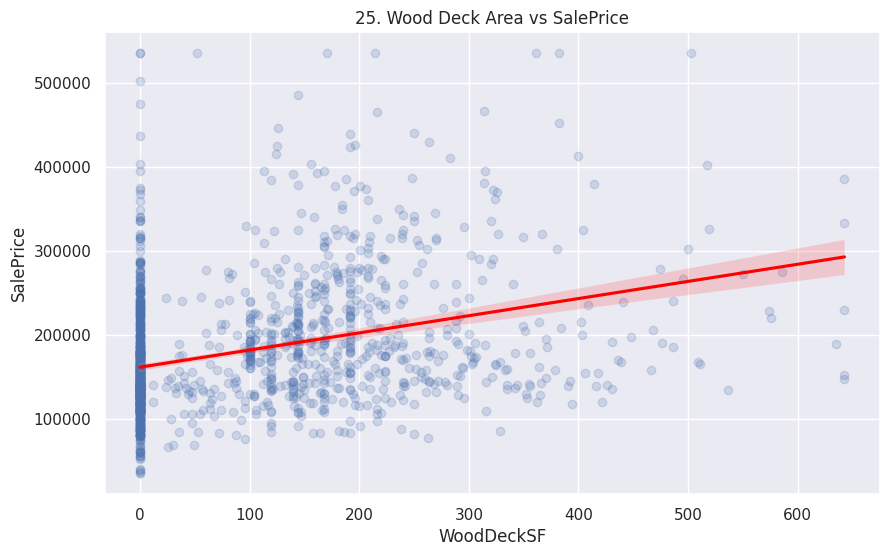

In [101]:
# 25. Wood Deck Area vs SalePrice
plt.figure(figsize=(10, 6))
sns.regplot(x='WoodDeckSF', y='SalePrice', data=plot_df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('25. Wood Deck Area vs SalePrice')
plt.show()

In [35]:
cat_cols, num_cols, cat_but_car, num_but_cat = grab_col_names(df2)

Observations: 2919
Variables: 281
cat_cols: 260
num_cols: 21
cat_but_car: 0
num_but_cat: 260


In [36]:
num_cols.remove("Id")
num_cols.remove("SalePrice")

In [37]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
rs = RobustScaler()
df2[num_cols] = rs.fit_transform(df2[num_cols])

In [38]:
df2.head()

,Id,LotFrontage,LotArea,Street,Utilities,Condition2,YearBuilt,YearRemodAdd,RoofMatl,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,SalePrice,YrBltAndRemod,Totallot,MSSubClass_160,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_Rare,MSZoning_RL,MSZoning_RM,MSZoning_Rare,Alley_NA,Alley_Pave,LotShape_IR2,LotShape_Rare,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_Inside,LotConfig_Rare,LandSlope_Mod,LandSlope_Rare,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_Rare,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Condition1_Feedr,Condition1_Norm,Condition1_PosN,Condition1_RRAn,Condition1_Rare,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_Rare,HouseStyle_SFoyer,HouseStyle_SLvl,OverallQual_2.0,OverallQual_3.0,OverallQual_4.0,OverallQual_5.0,OverallQual_6.0,OverallQual_7.0,OverallQual_8.0,OverallQual_9.0,OverallQual_10.0,OverallCond_4,OverallCond_5,OverallCond_6,OverallCond_7,OverallCond_8,OverallCond_9,OverallCond_Rare,RoofStyle_Hip,RoofStyle_Rare,Exterior1st_BrkFace,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Rare,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_BrkFace,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Rare,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_None,MasVnrType_Rare,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Gd,ExterCond_Rare,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Rare,Foundation_Slab,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_NA,BsmtQual_TA,BsmtCond_Gd,BsmtCond_NA,BsmtCond_Rare,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_NA,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_NA,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_NA,BsmtFinType2_Rec,BsmtFinType2_Unf,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Rare,HeatingQC_TA,Electrical_FuseF,Electrical_Rare,Electrical_SBrkr,BsmtFullBath_1.0,BsmtFullBath_2.0,BsmtFullBath_3.0,BsmtHalfBath_1.0,BsmtHalfBath_2.0,FullBath_1,FullBath_2,FullBath_3,FullBath_4,HalfBath_1,HalfBath_2,BedroomAbvGr_1,BedroomAbvGr_2,BedroomAbvGr_3,BedroomAbvGr_4,BedroomAbvGr_5,BedroomAbvGr_6,BedroomAbvGr_8,KitchenAbvGr_1,KitchenAbvGr_2,KitchenAbvGr_3,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,TotRmsAbvGrd_3.0,TotRmsAbvGrd_4.0,TotRmsAbvGrd_5.0,TotRmsAbvGrd_6.0,TotRmsAbvGrd_7.0,TotRmsAbvGrd_8.0,TotRmsAbvGrd_9.0,TotRmsAbvGrd_10.0,TotRmsAbvGrd_11.0,TotRmsAbvGrd_12.0,TotRmsAbvGrd_12.5,Functional_Min2,Functional_Mod,Functional_Rare,Functional_Typ,Fireplaces_1,Fireplaces_2,Fireplaces_3,Fireplaces_4,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_NA,FireplaceQu_Po,FireplaceQu_TA,GarageType_Basment,GarageType_BuiltIn,GarageType_Detchd,GarageType_NA,GarageType_Rare,GarageFinish_NA,GarageFinish_RFn,GarageFinish_Unf,GarageCars_1.0,GarageCars_2.0,GarageCars_3.0,GarageCars_4.0,GarageCars_5.0,GarageQual_NA,GarageQual_Rare,GarageQual_TA,GarageCond_NA,GarageCond_Rare,GarageCond_TA,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_NA,Fence_Rare,MiscFeature_Rare,MiscFeature_Shed,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2

# Model

In [39]:
# Separating Train and Test data

train = df2[:row_train]
test_1 = df2[row_train:]

In [40]:
# Build a model with train data

X = train.drop(['SalePrice','Id'], axis=1)
y = train['SalePrice']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [42]:
y_train= y_train.values.reshape(-1,1)
y_test= y_test.values.reshape(-1,1)
y_train = np.log(y_train)
y_test = np.log(y_test)

# LinearRegression

In [43]:
reg_model = LinearRegression().fit(X_train, y_train)
reg_pred = reg_model.predict(X_test)

In [44]:
print('MAE:', metrics.mean_absolute_error(y_test, reg_pred))
print('MSE:', metrics.mean_squared_error(y_test, reg_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, reg_pred)))

MAE: 0.09172348299610782
MSE: 0.02755898866688674
RMSE: 0.1660090017646234


In [45]:
liner_r2_score=r2_score(y_test, reg_pred)
liner_r2_score

0.8299606723412197

# CatBoost

In [46]:
cb_model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
cb_model.fit(X_train, y_train)
preds = cb_model.predict(X_test)

In [47]:
print('MAE:', metrics.mean_absolute_error(y_test, preds))
print('MSE:', metrics.mean_squared_error(y_test, preds))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, preds)))

MAE: 0.08481823257258944
MSE: 0.01723765512262422
RMSE: 0.13129225080949836


In [48]:
cb_r2_score=r2_score(y_test, preds)
cb_r2_score

0.893643437976127

# XGB

In [49]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

In [50]:
print('MAE:', metrics.mean_absolute_error(y_test, xgb_preds))
print('MSE:', metrics.mean_squared_error(y_test, xgb_preds))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, xgb_preds)))

MAE: 0.10005328541694311
MSE: 0.023194553072044863
RMSE: 0.1522975806506619


In [51]:
xgb_r2_score=r2_score(y_test, xgb_preds)
xgb_r2_score

0.8568892981746001

# HyperParameter Optimization

In [52]:
# CatBoost Regressor

cb = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
cb_params = {"iterations": [300, 350],
                   "learning_rate": [0.1, 0.2],
                   "depth": [3, 5]}
cb_random = GridSearchCV(estimator=cb,param_grid=cb_params, n_jobs=-1)

cb_random.fit(X_train, y_train)

GridSearchCV(estimator=CatBoostRegressor(logging_level='Silent', loss_function='RMSE'),
             n_jobs=-1,
             param_grid={'depth': [3, 5], 'iterations': [300, 350],
                         'learning_rate': [0.1, 0.2]})

In [53]:
print(cb_random.best_params_)

final_model = cb.set_params(**cb_random.best_params_, random_state=17).fit(X_train, y_train)

{'depth': 5, 'iterations': 350, 'learning_rate': 0.1}


In [54]:
cat_pred = final_model.predict(X_test)
print('MAE:', metrics.mean_absolute_error(y_test, cat_pred))
print('MSE:', metrics.mean_squared_error(y_test, cat_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, cat_pred)))
print('r2_score:', r2_score(y_test, cat_pred))

MAE: 0.084753797491448
MSE: 0.017054049367425744
RMSE: 0.13059115348072298
r2_score: 0.8947762879346505


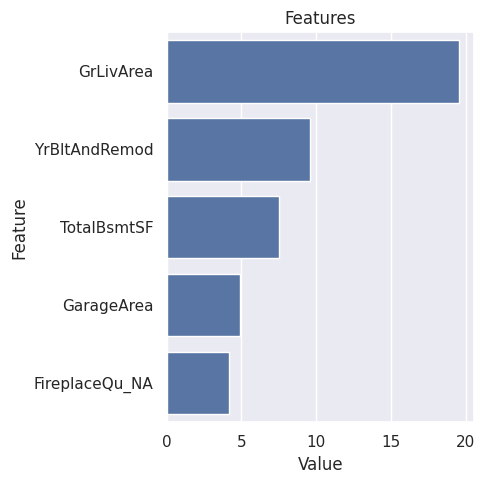

In [55]:
# Variable severity

def plot_importance(model, features, num=5, save=False):

    feature_imp = pd.DataFrame({"Value": model.feature_importances_, "Feature": features.columns})
    plt.figure(figsize=(5, 5))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title("Features")
    plt.tight_layout()
    plt.show()

plot_importance(final_model, X)

In [56]:
Sub = test_1.drop(["Id",'SalePrice'], axis=1)
Sub.head()

,LotFrontage,LotArea,Street,Utilities,Condition2,YearBuilt,YearRemodAdd,RoofMatl,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,YrBltAndRemod,Totallot,MSSubClass_160,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_Rare,MSZoning_RL,MSZoning_RM,MSZoning_Rare,Alley_NA,Alley_Pave,LotShape_IR2,LotShape_Rare,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_Inside,LotConfig_Rare,LandSlope_Mod,LandSlope_Rare,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_Rare,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Condition1_Feedr,Condition1_Norm,Condition1_PosN,Condition1_RRAn,Condition1_Rare,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_Rare,HouseStyle_SFoyer,HouseStyle_SLvl,OverallQual_2.0,OverallQual_3.0,OverallQual_4.0,OverallQual_5.0,OverallQual_6.0,OverallQual_7.0,OverallQual_8.0,OverallQual_9.0,OverallQual_10.0,OverallCond_4,OverallCond_5,OverallCond_6,OverallCond_7,OverallCond_8,OverallCond_9,OverallCond_Rare,RoofStyle_Hip,RoofStyle_Rare,Exterior1st_BrkFace,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Rare,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_BrkFace,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Rare,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_None,MasVnrType_Rare,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Gd,ExterCond_Rare,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Rare,Foundation_Slab,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_NA,BsmtQual_TA,BsmtCond_Gd,BsmtCond_NA,BsmtCond_Rare,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_NA,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_NA,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_NA,BsmtFinType2_Rec,BsmtFinType2_Unf,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Rare,HeatingQC_TA,Electrical_FuseF,Electrical_Rare,Electrical_SBrkr,BsmtFullBath_1.0,BsmtFullBath_2.0,BsmtFullBath_3.0,BsmtHalfBath_1.0,BsmtHalfBath_2.0,FullBath_1,FullBath_2,FullBath_3,FullBath_4,HalfBath_1,HalfBath_2,BedroomAbvGr_1,BedroomAbvGr_2,BedroomAbvGr_3,BedroomAbvGr_4,BedroomAbvGr_5,BedroomAbvGr_6,BedroomAbvGr_8,KitchenAbvGr_1,KitchenAbvGr_2,KitchenAbvGr_3,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,TotRmsAbvGrd_3.0,TotRmsAbvGrd_4.0,TotRmsAbvGrd_5.0,TotRmsAbvGrd_6.0,TotRmsAbvGrd_7.0,TotRmsAbvGrd_8.0,TotRmsAbvGrd_9.0,TotRmsAbvGrd_10.0,TotRmsAbvGrd_11.0,TotRmsAbvGrd_12.0,TotRmsAbvGrd_12.5,Functional_Min2,Functional_Mod,Functional_Rare,Functional_Typ,Fireplaces_1,Fireplaces_2,Fireplaces_3,Fireplaces_4,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_NA,FireplaceQu_Po,FireplaceQu_TA,GarageType_Basment,GarageType_BuiltIn,GarageType_Detchd,GarageType_NA,GarageType_Rare,GarageFinish_NA,GarageFinish_RFn,GarageFinish_Unf,GarageCars_1.0,GarageCars_2.0,GarageCars_3.0,GarageCars_4.0,GarageCars_5.0,GarageQual_NA,GarageQual_Rare,GarageQual_TA,GarageCond_NA,GarageCond_Rare,GarageCond_TA,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_NA,Fence_Rare,MiscFeature_Rare,MiscFeature_Shed,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_

In [57]:
Sub_pred=cb.predict(Sub)
Sub_pred= Sub_pred.reshape(-1,1)
Sub_pred =np.exp(Sub_pred)

In [58]:
Submissions= pd.DataFrame()
Submissions["Id"] = test_ID
Submissions['SalePrice'] = Sub_pred
Submissions.head()

,Id,SalePrice
0,1461,128613.423471
1,1462,161875.119896
2,1463,201241.926465
3,1464,204332.963564
4,1465,182906.548866


### 3. Model Evaluation & Diagnostics
Comparing model performance metrics and checking error distributions.

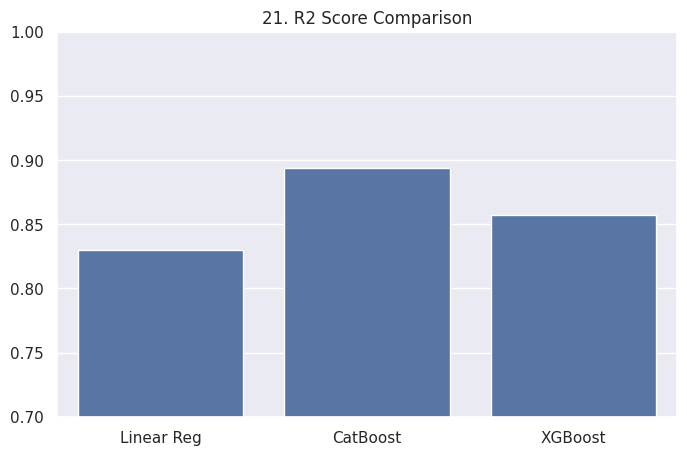

In [102]:
# 21. Model R2 Comparison
models_list = ['Linear Reg', 'CatBoost', 'XGBoost']
scores_list = [liner_r2_score, cb_r2_score, xgb_r2_score]
plt.figure(figsize=(8, 5))
sns.barplot(x=models_list, y=scores_list)
plt.ylim(0.7, 1.0)
plt.title('21. R2 Score Comparison')
plt.show()

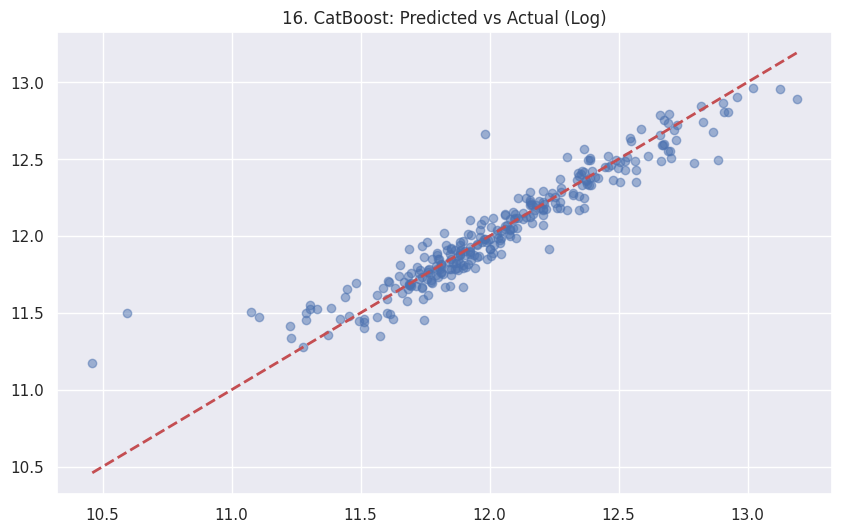

In [103]:
# 16. Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, cat_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('16. CatBoost: Predicted vs Actual (Log)')
plt.show()

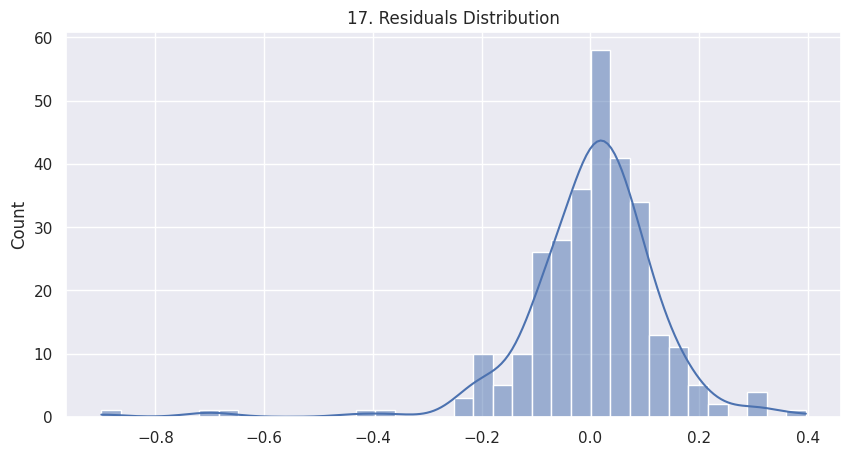

In [104]:
# 17. Residuals Distribution
residuals = y_test.flatten() - cat_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title('17. Residuals Distribution')
plt.show()

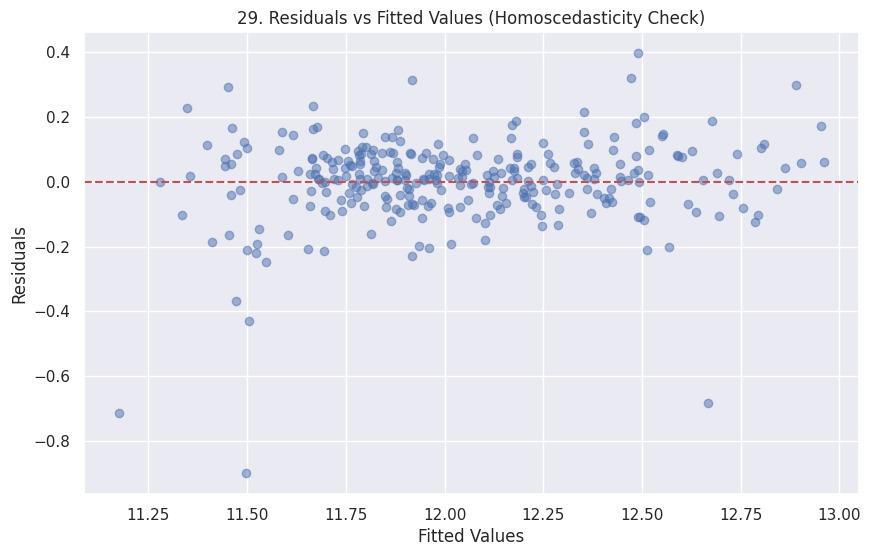

In [105]:
# 29. Residuals vs Fitted Values
plt.figure(figsize=(10, 6))
plt.scatter(cat_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('29. Residuals vs Fitted Values (Homoscedasticity Check)')
plt.show()

In [59]:
Submissions.to_csv('Submissions.csv',index=False)

### 4. Advanced Enhancements: Feature Interactions & Model Stacking
In this section, we refine our features and combine our models into an ensemble to capture more complex patterns in the data.

In [107]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# 1. Feature Interactions using original numeric values from all_data
# Since OverallQual was one-hot encoded in df2, we calculate the interaction using the original numeric data
interaction = all_data['OverallQual'] * all_data['GrLivArea']
df2['Qual_Area_Interact'] = interaction

# Re-split since we added a feature to df2
train_adv = df2[:row_train]
test_adv_final = df2[row_train:]

X_advanced = train_adv.drop(['SalePrice','Id'], axis=1)
y_advanced = np.log(train_adv['SalePrice'])

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_advanced, y_advanced, test_size=0.2, random_state=42)

# 2. Define Base Models for Stacking
estimators = [
    ('cat', CatBoostRegressor(iterations=350, depth=5, learning_rate=0.1, logging_level='Silent', random_state=17)),
    ('xgb', XGBRegressor(n_estimators=1000, max_depth=5, learning_rate=0.05, random_state=17))
]

# 3. Build and Fit Stacking Regressor
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV()
)

stacking_model.fit(X_train_adv, y_train_adv.ravel())
stack_pred = stacking_model.predict(X_test_adv)

print('Ensemble R2 Score:', r2_score(y_test_adv, stack_pred))
print('Ensemble RMSE:', np.sqrt(mean_squared_error(y_test_adv, stack_pred)))

/tmp/ipykernel_17631/3597499944.py:30: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  stacking_model.fit(X_train_adv, y_train_adv.ravel())


Ensemble R2 Score: 0.8960665449032064
Ensemble RMSE: 0.1375051144838682


### 5. Custom Price Prediction
In this section, we create a function to predict the price of a house given specific input features. This demonstrates how the model can be deployed for real-world use cases.

In [108]:
import pandas as pd
import numpy as np

def predict_custom_house(input_data, train_cols, scaler, model):
    # 1. Create a template dataframe with all columns from the training set set to 0/False
    input_df = pd.DataFrame(0, index=[0], columns=train_cols)

    # 2. Fill in the provided numeric values
    numeric_feats = ['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
                     'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
                     '2ndFlrSF', 'GrLivArea', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF',
                     'OpenPorchSF', 'EnclosedPorch']

    for feat in numeric_feats:
        if feat in input_data:
            input_df[feat] = input_data[feat]

    # 3. Handle engineered features
    input_df['YrBltAndRemod'] = input_df['YearBuilt'] + input_df['YearRemodAdd']
    input_df['Totallot'] = input_df['LotFrontage'] + input_df['LotArea']
    input_df['Qual_Area_Interact'] = input_data.get('OverallQual', 5) * input_df['GrLivArea']

    # 4. Handle One-Hot Encoded Categorical columns
    # Example: if input_data['MSZoning'] == 'RL', set 'MSZoning_RL' to 1
    for col, value in input_data.items():
        ohe_col = f"{col}_{value}"
        if ohe_col in input_df.columns:
            input_df[ohe_col] = 1

    # 5. Apply Scaling to numerical columns
    input_df[num_cols] = scaler.transform(input_df[num_cols])

    # 6. Predict (Result is in Log, so we transform back using exp)
    log_prediction = model.predict(input_df)
    return np.exp(log_prediction)[0]

# Example Custom Input
my_house = {
    'OverallQual': 9,      # High Quality (1-10)
    'GrLivArea': 2500,     # Large Living Area
    'TotalBsmtSF': 1200,
    'YearBuilt': 2015,
    'YearRemodAdd': 2016,
    'GarageCars': 3.0,
    'FullBath': 2,
    'Neighborhood': 'CollgCr',
    'MSZoning': 'RL',
    'CentralAir': 'Y'
}

predicted_price = predict_custom_house(my_house, X_advanced.columns, rs, stacking_model)
print(f"Predicted Sale Price for the custom house: ${predicted_price:,.2f}")

Predicted Sale Price for the custom house: $191,414.03


In [109]:
import joblib
from google.colab import files

# 1. Save the model and preprocessing assets
joblib.dump(stacking_model, 'house_model.pkl')
joblib.dump(rs, 'scaler.pkl')
joblib.dump(X_advanced.columns.tolist(), 'features.pkl')

print("Assets saved to Colab environment. Starting downloads...")

# 2. Download the files to your local machine
for filename in ['house_model.pkl', 'scaler.pkl', 'features.pkl']:
    files.download(filename)

Assets saved to Colab environment. Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 6. Streamlit Web Application Development
In this section, we create the frontend for our model using Streamlit. This code writes an `app.py` file that can be used to launch a web dashboard.

In [ ]:
streamlit_code = """
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Set page config
st.set_page_config(page_title='House Price Predictor', layout='wide')

@st.cache_resource
def load_assets():
    model = joblib.load('house_model.pkl')
    scaler = joblib.load('scaler.pkl')
    features = joblib.load('features.pkl')
    return model, scaler, features

model, scaler, train_cols = load_assets()

def predict_price(input_dict):
    input_df = pd.DataFrame(0, index=[0], columns=train_cols)

    # Numeric mapping
    numeric_feats = ['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
                     'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
                     '2ndFlrSF', 'GrLivArea', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF',
                     'OpenPorchSF', 'EnclosedPorch']

    for feat in numeric_feats:
        if feat in input_dict: input_df[feat] = input_dict[feat]

    # Engineering
    input_df['YrBltAndRemod'] = input_dict['YearBuilt'] + input_dict['YearRemodAdd']
    input_df['Totallot'] = input_dict['LotFrontage'] + input_dict['LotArea']
    input_df['Qual_Area_Interact'] = input_dict['OverallQual'] * input_dict['GrLivArea']

    # OHE
    for col, val in input_dict.items():
        ohe_name = f"{col}_{val}"
        if ohe_name in input_df.columns: input_df[ohe_name] = 1

    # Scale (Ensure num_cols used in training are matched here)
    num_cols_to_scale = ['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
                         'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
                         '2ndFlrSF', 'GrLivArea', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF',
                         'OpenPorchSF', 'EnclosedPorch', 'YrBltAndRemod', 'Totallot']

    input_df[num_cols_to_scale] = scaler.transform(input_df[num_cols_to_scale])

    log_pred = model.predict(input_df)
    return np.exp(log_pred)[0]

st.title("🏠 House Price Prediction Dashboard")
st.markdown("Enter house details to estimate the Sale Price.")

col1, col2 = st.columns(2)

with col1:
    overall_qual = st.slider("Overall Quality (1-10)", 1, 10, 5)
    gr_liv_area = st.number_input("Ground Living Area (sqft)", 300, 6000, 1500)
    total_bsmt = st.number_input("Total Basement Area (sqft)", 0, 6000, 1000)
    year_built = st.number_input("Year Built", 1800, 2024, 2000)

with col2:
    neighborhood = st.selectbox("Neighborhood", ['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst', 'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes', 'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU', 'Blueste'])
    ms_zoning = st.selectbox("Zoning", ['RL', 'RM', 'C (all)', 'FV', 'RH'])
    garage_cars = st.selectbox("Garage Capacity (Cars)", [0, 1, 2, 3, 4])
    central_air = st.radio("Central Air", ['Y', 'N'])

if st.button("Estimate Price"):
    user_input = {
        'OverallQual': overall_qual,
        'GrLivArea': gr_liv_area,
        'TotalBsmtSF': total_bsmt,
        'YearBuilt': year_built,
        'YearRemodAdd': year_built,
        'Neighborhood': neighborhood,
        'MSZoning': ms_zoning,
        'GarageCars': garage_cars,
        'CentralAir': central_air
    }

    prediction = predict_price(user_input)
    st.success(f"### Estimated Sale Price: ${prediction:,.2f}")
"""

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("app.py has been generated.")
from google.colab import files
files.download('app.py')

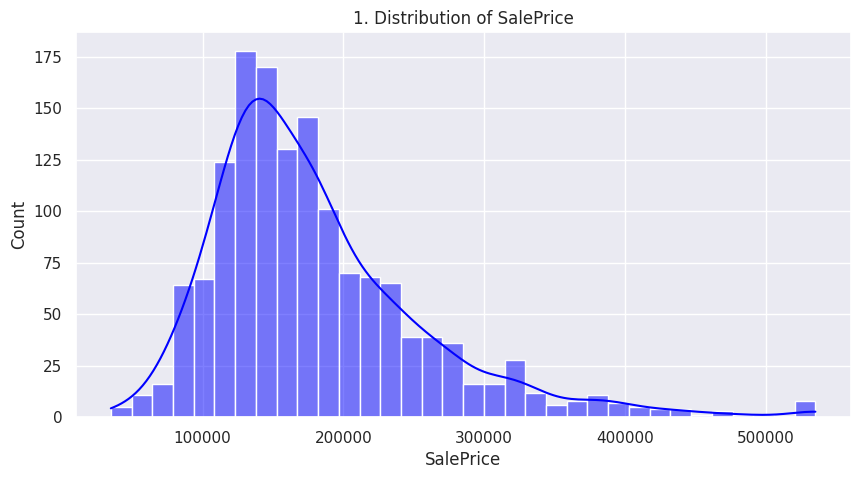

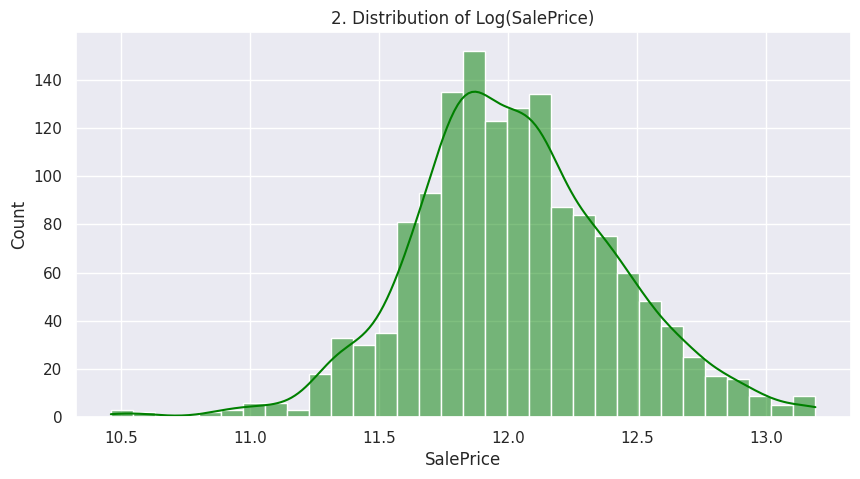

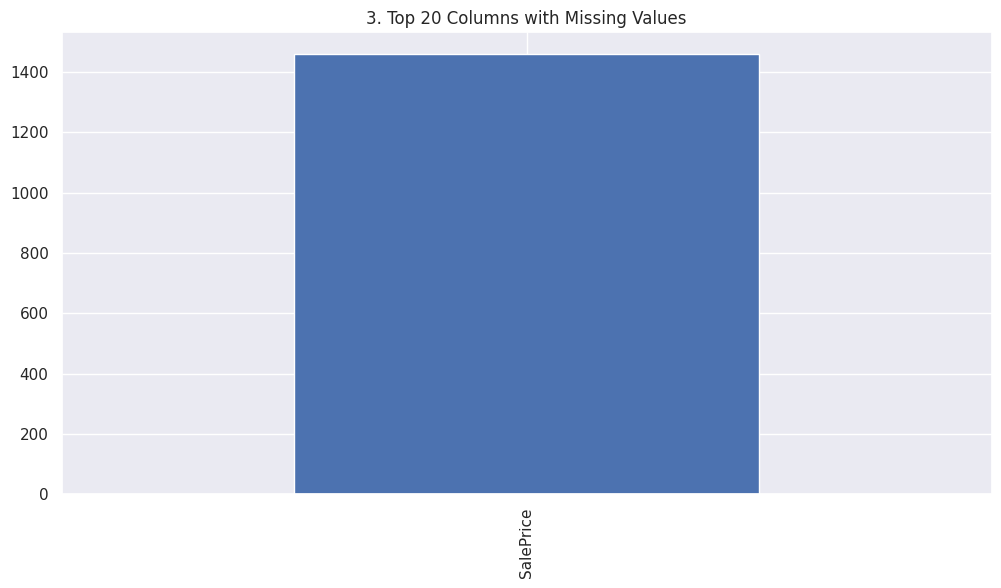

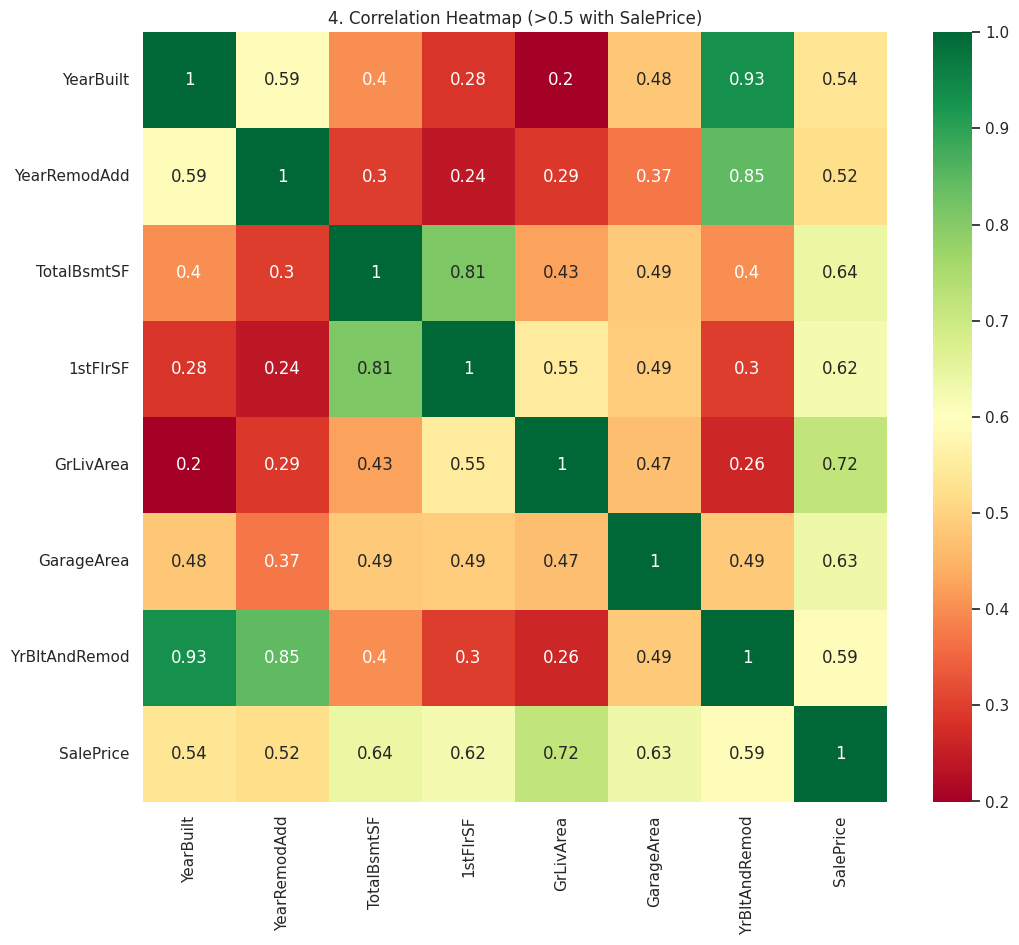

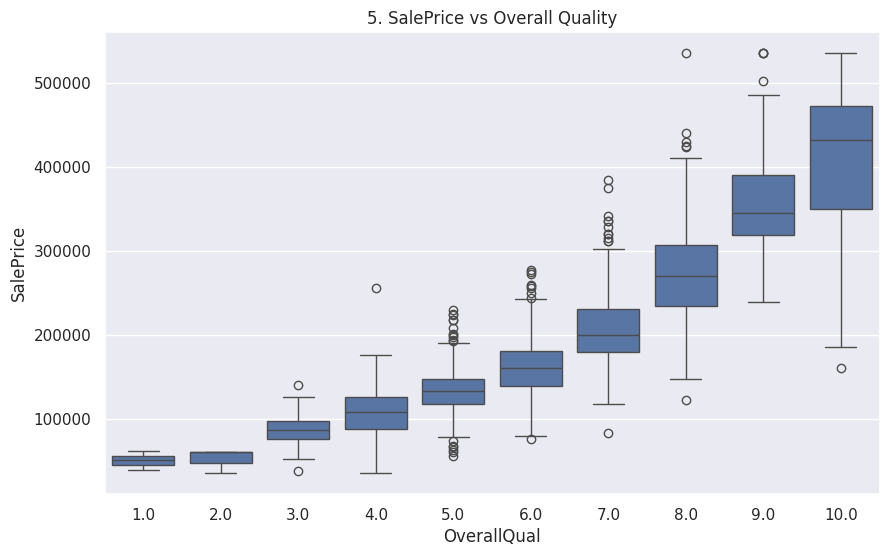

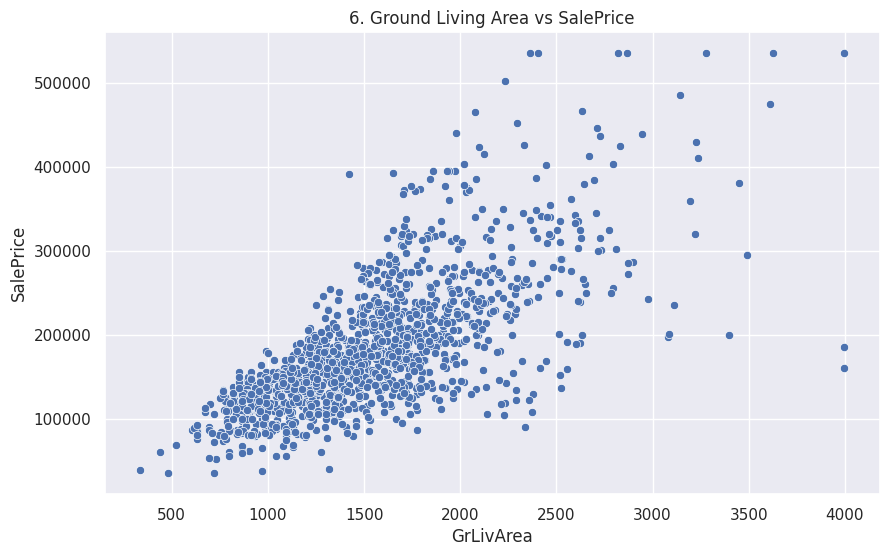

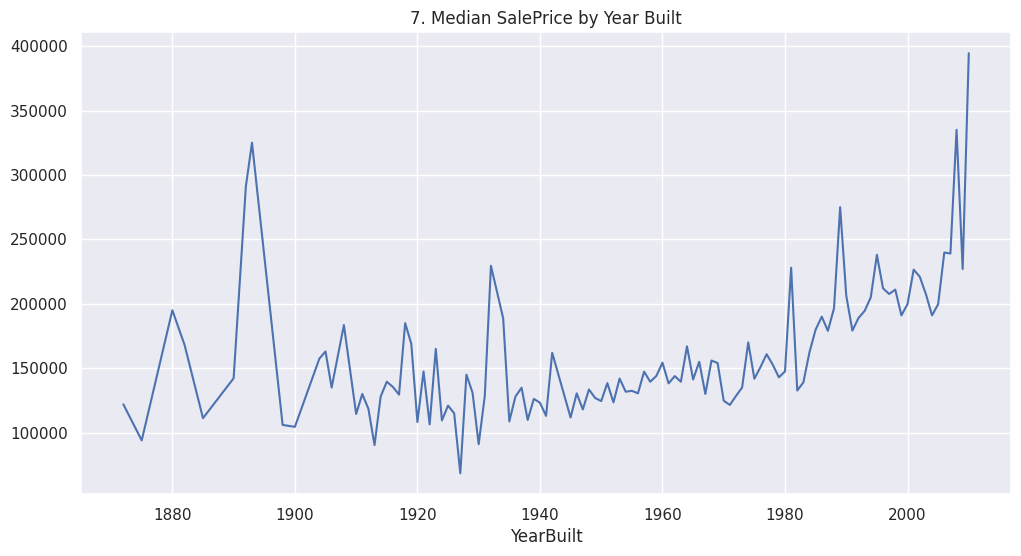

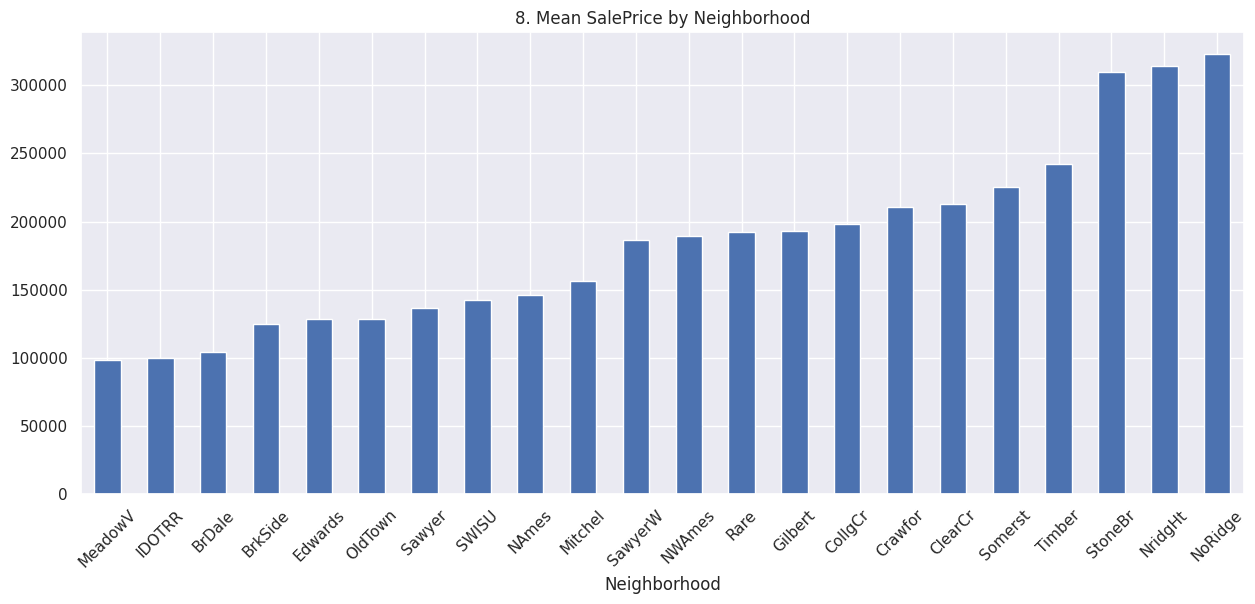

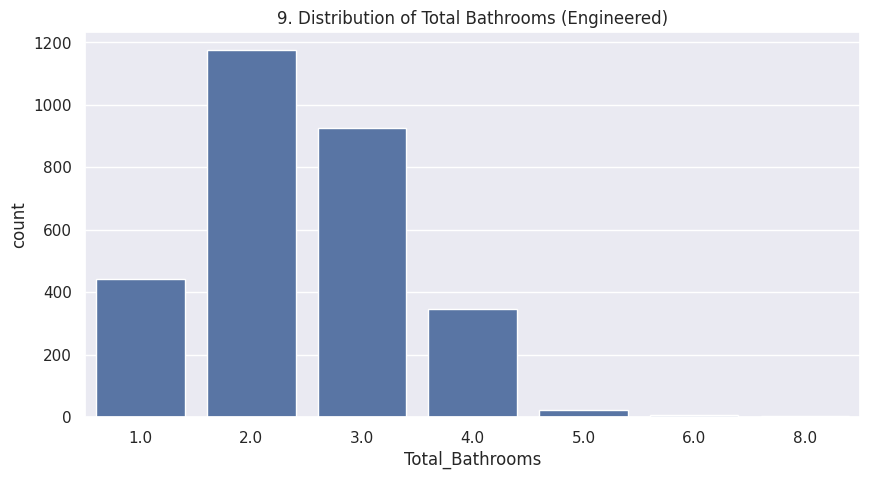

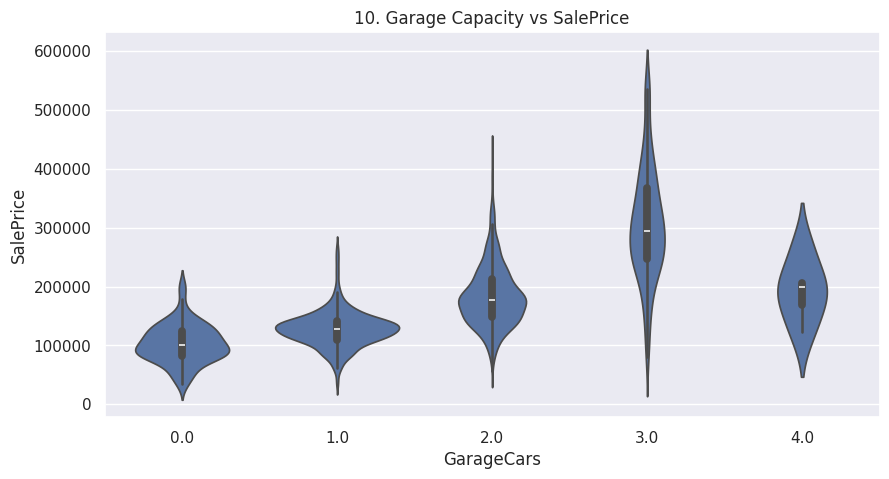

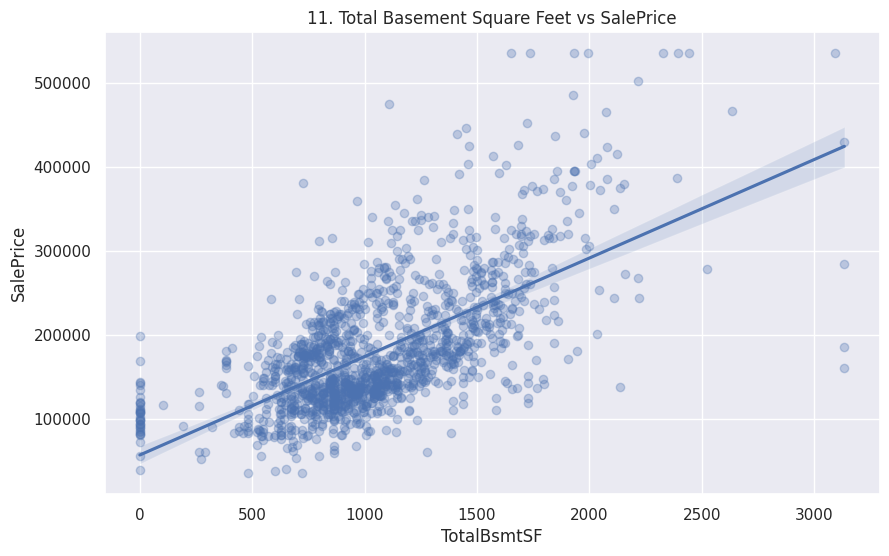

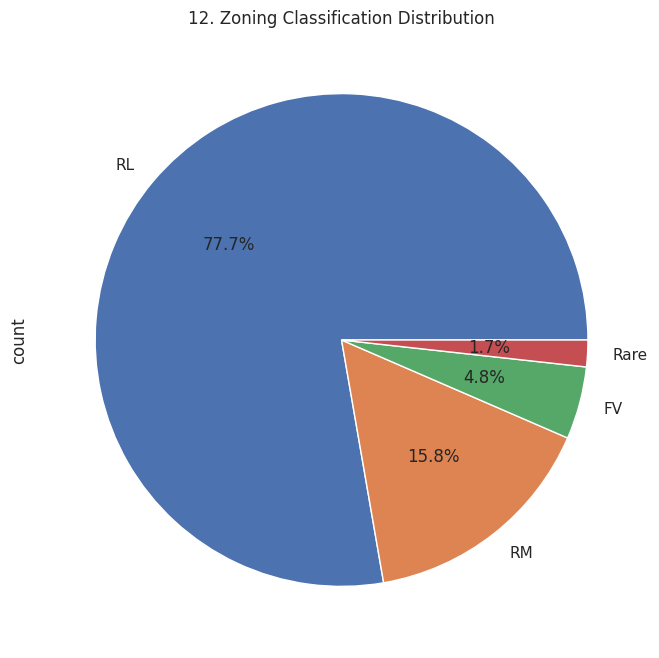

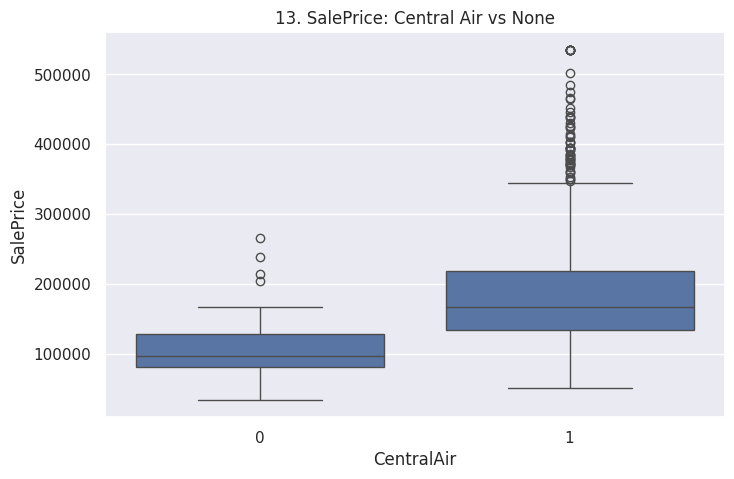

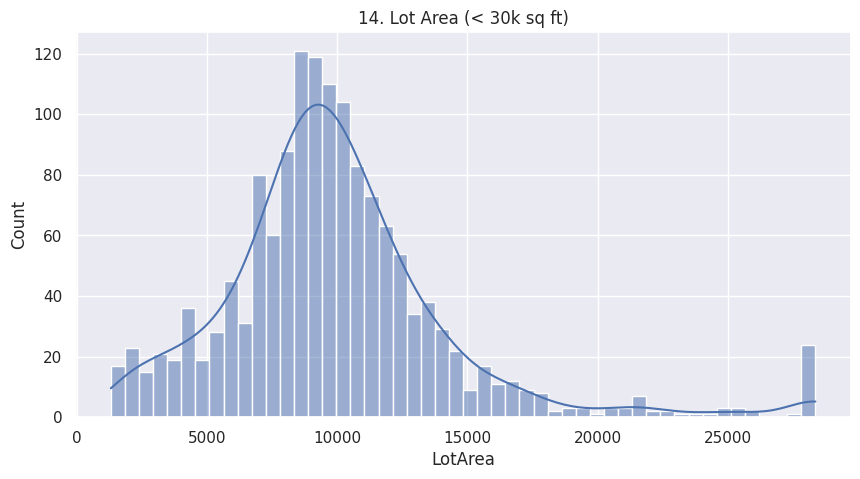

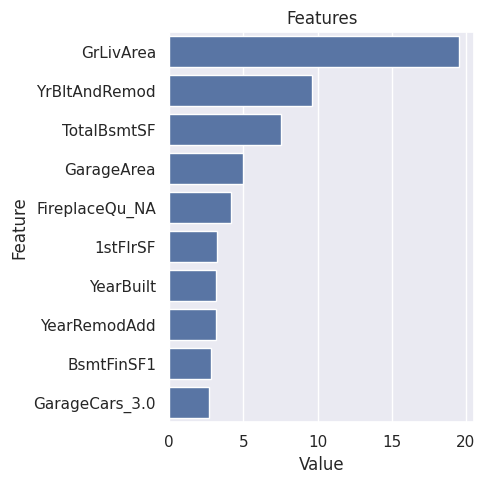

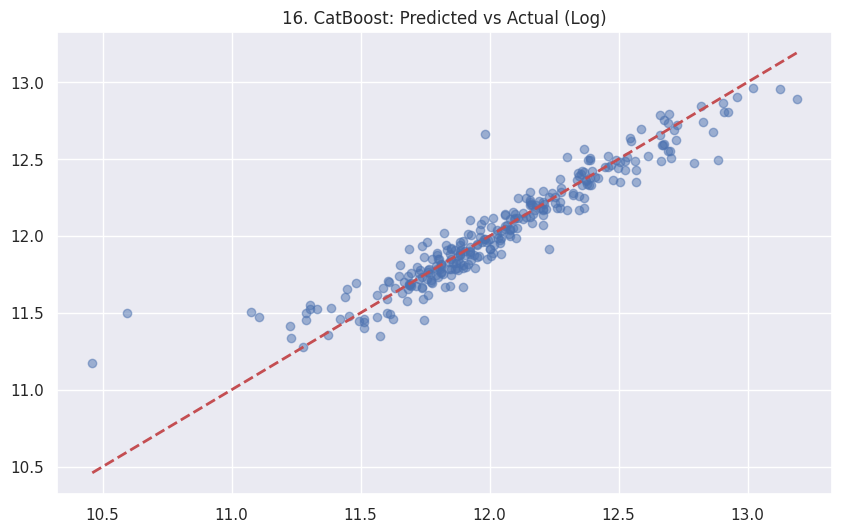

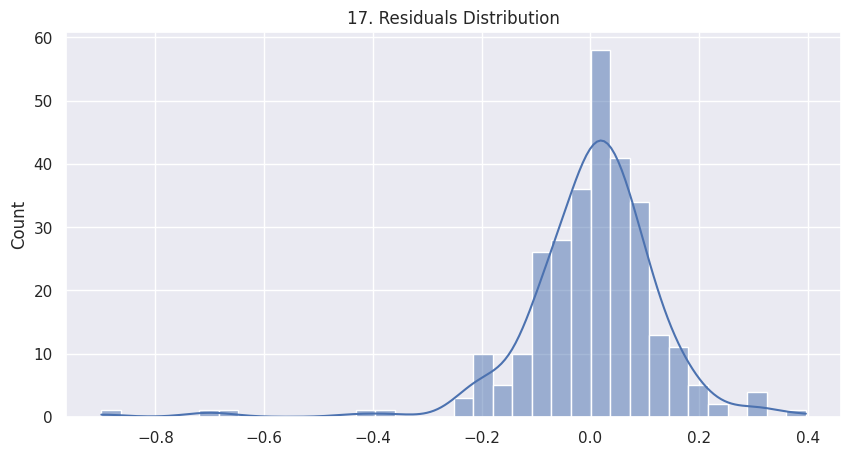

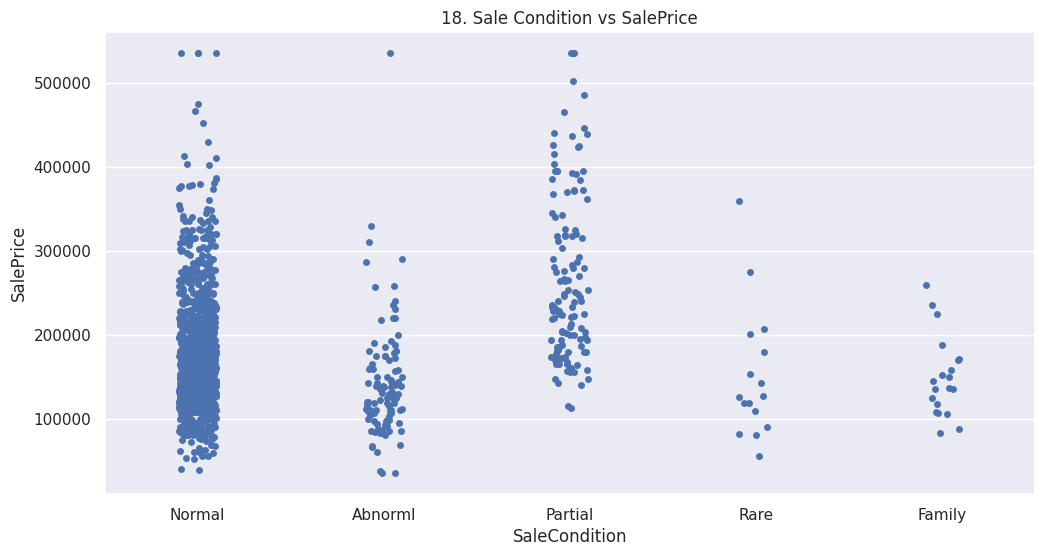

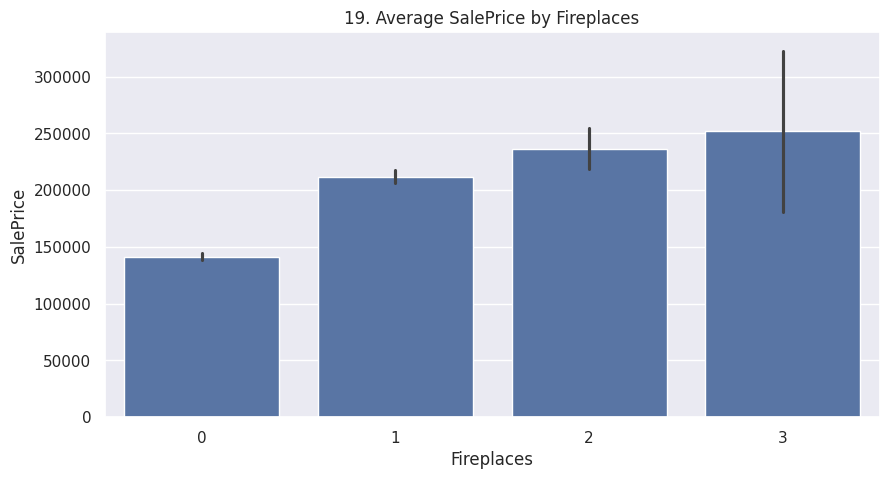

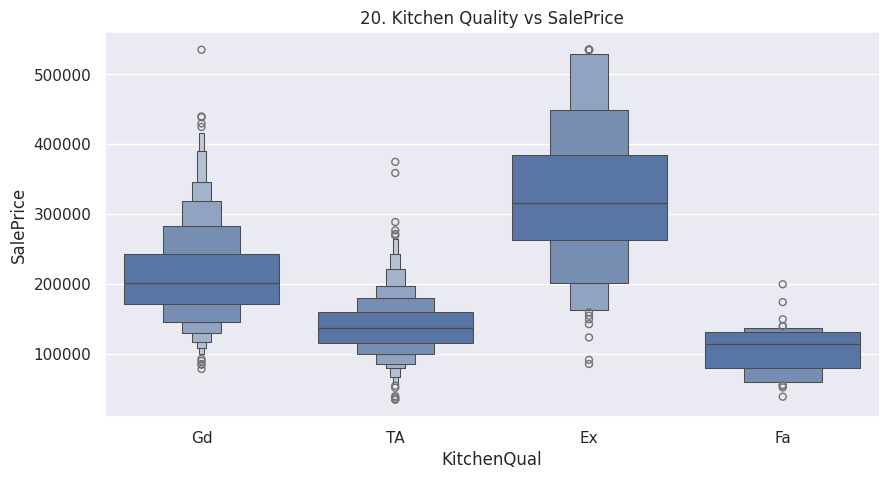

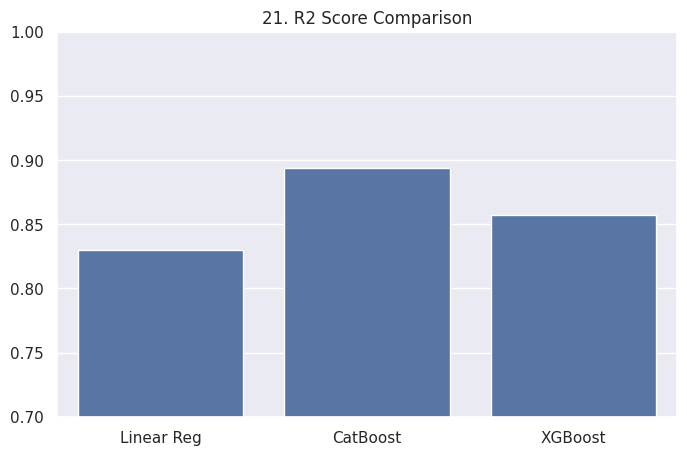

In [61]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Creating a temporary dataframe for original categorical plotting
plot_df = all_data.iloc[:row_train].copy()

# 1. Target Variable Distribution
plt.figure(figsize=(10, 5))
sns.histplot(plot_df['SalePrice'], kde=True, color='blue')
plt.title('1. Distribution of SalePrice')
plt.show()

# 2. Log-Transformed Target Distribution
plt.figure(figsize=(10, 5))
sns.histplot(np.log(plot_df['SalePrice']), kde=True, color='green')
plt.title('2. Distribution of Log(SalePrice)')
plt.show()

# 3. Missing Values Heatmap (Top 20)
plt.figure(figsize=(12, 6))
missing = all_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)[:20]
if not missing.empty:
    missing.plot(kind='bar')
    plt.title('3. Top 20 Columns with Missing Values')
    plt.show()

# 4. Correlation Heatmap (Numerical)
plt.figure(figsize=(12, 10))
corr_matrix = plot_df[num_cols + ['SalePrice']].corr()
top_corr_features = corr_matrix.index[abs(corr_matrix['SalePrice']) > 0.5]
sns.heatmap(plot_df[top_corr_features].corr(), annot=True, cmap='RdYlGn')
plt.title('4. Correlation Heatmap (>0.5 with SalePrice)')
plt.show()

# 5. OverallQual vs SalePrice Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=plot_df)
plt.title('5. SalePrice vs Overall Quality')
plt.show()

# 6. GrLivArea vs SalePrice Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=plot_df)
plt.title('6. Ground Living Area vs SalePrice')
plt.show()

# 7. YearBuilt vs SalePrice LinePlot
plt.figure(figsize=(12, 6))
plot_df.groupby('YearBuilt')['SalePrice'].median().plot()
plt.title('7. Median SalePrice by Year Built')
plt.show()

# 8. Neighborhood vs SalePrice
plt.figure(figsize=(15, 6))
plot_df.groupby('Neighborhood')['SalePrice'].mean().sort_values().plot(kind='bar')
plt.title('8. Mean SalePrice by Neighborhood')
plt.xticks(rotation=45)
plt.show()

# 9. Total Bathrooms Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='Total_Bathrooms', data=all_data)
plt.title('9. Distribution of Total Bathrooms (Engineered)')
plt.show()

# 10. GarageCars vs SalePrice
plt.figure(figsize=(10, 5))
sns.violinplot(x='GarageCars', y='SalePrice', data=plot_df)
plt.title('10. Garage Capacity vs SalePrice')
plt.show()

# 11. TotalBsmtSF vs SalePrice
plt.figure(figsize=(10, 6))
sns.regplot(x='TotalBsmtSF', y='SalePrice', data=plot_df, scatter_kws={'alpha':0.3})
plt.title('11. Total Basement Square Feet vs SalePrice')
plt.show()

# 12. MSZoning Distribution
plt.figure(figsize=(8, 8))
all_data['MSZoning'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('12. Zoning Classification Distribution')
plt.show()

# 13. CentralAir Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='CentralAir', y='SalePrice', data=plot_df)
plt.title('13. SalePrice: Central Air vs None')
plt.show()

# 14. LotArea Distribution
plt.figure(figsize=(10, 5))
sns.histplot(plot_df[plot_df['LotArea'] < 30000]['LotArea'], bins=50, kde=True)
plt.title('14. Lot Area (< 30k sq ft)')
plt.show()

# 15. Feature Importance
plot_importance(final_model, X, num=10)

# 16. Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, cat_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('16. CatBoost: Predicted vs Actual (Log)')
plt.show()

# 17. Residuals
residuals = y_test.flatten() - cat_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title('17. Residuals Distribution')
plt.show()

# 18. SaleCondition vs SalePrice
plt.figure(figsize=(12, 6))
sns.stripplot(x='SaleCondition', y='SalePrice', data=plot_df, jitter=True)
plt.title('18. Sale Condition vs SalePrice')
plt.show()

# 19. Fireplaces vs SalePrice
plt.figure(figsize=(10, 5))
sns.barplot(x='Fireplaces', y='SalePrice', data=plot_df)
plt.title('19. Average SalePrice by Fireplaces')
plt.show()

# 20. KitchenQual vs SalePrice
plt.figure(figsize=(10, 5))
sns.boxenplot(x='KitchenQual', y='SalePrice', data=plot_df)
plt.title('20. Kitchen Quality vs SalePrice')
plt.show()

# 21. Model R2 Comparison
models_list = ['Linear Reg', 'CatBoost', 'XGBoost']
scores_list = [liner_r2_score, cb_r2_score, xgb_r2_score]
plt.figure(figsize=(8, 5))
sns.barplot(x=models_list, y=scores_list)
plt.ylim(0.7, 1.0)
plt.title('21. R2 Score Comparison')
plt.show()